# ISE 571 Term Paper
This notebook reproduces the methodology from the paper on Robust Nonlinear Support Vector Machines. We implement deterministic and robust SVM models across multiple datasets to evaluate performance under uncertainty. All experiments strictly follow the protocol described in the original paper. 6 out of 12 datasets from the original paper will be used here for reproduction.

In [3]:
#Installing necessary libraries
%pip install -q numpy pandas matplotlib seaborn scikit-learn cvxpy clarabel tqdm

Note: you may need to restart the kernel to use updated packages.


In [1]:
# Importing necessary libraries

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer

import cvxpy as cp
import clarabel

from tqdm import tqdm
from sklearn.metrics import precision_score, recall_score, f1_score, accuracy_score

np.random.seed(42)

print("All libraries imported successfully.")

All libraries imported successfully.


# Dataset - Iris (Multiclass, Simple Baseline)

In [2]:
#Importing dataset

iris_url = "https://raw.githubusercontent.com/husseinareefurrahman-collab/ISE521-Term-Paper/refs/heads/main/iris.data"

iris_df = pd.read_csv(iris_url, header=None)

iris_df.columns = ["f1", "f2", "f3", "f4", "class"]

iris_df["class"] = iris_df["class"].astype("category").cat.codes

X_iris = iris_df.drop(columns=["class"]).values
y_iris = iris_df["class"].values

print("Iris dataset loaded successfully.")
print("Shape:", X_iris.shape)
print("Classes:", np.unique(y_iris))

Iris dataset loaded successfully.
Shape: (150, 4)
Classes: [0 1 2]


In [3]:
#Preprocessing

X_iris_processed = X_iris.copy()
y_iris_processed = y_iris.copy()

print("Preprocessing used: No transformation (as specified in the original paper)")

print("\nMissing values:", np.isnan(X_iris_processed).sum())
print("Feature shape:", X_iris_processed.shape)
print("Class distribution:")
print(pd.Series(y_iris_processed).value_counts().sort_index())

Preprocessing used: No transformation (as specified in the original paper)

Missing values: 0
Feature shape: (150, 4)
Class distribution:
0    50
1    50
2    50
Name: count, dtype: int64


Iris EDA Summary
----------------------------------------
Number of samples: 150
Number of features: 4
Number of classes: 3

Class distribution:
class
0    50
1    50
2    50
Name: count, dtype: int64

Feature summary:


,f1,f2,f3,f4,class
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.054000,3.758667,1.198667,1.000000
std,0.828066,0.433594,1.764420,0.763161,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


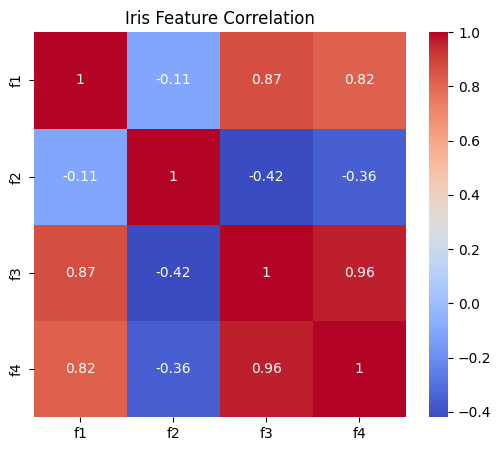

In [4]:
#EDA

iris_df_clean = pd.DataFrame(X_iris_processed, columns=["f1", "f2", "f3", "f4"])
iris_df_clean["class"] = y_iris_processed

print("Iris EDA Summary")
print("-" * 40)

print("Number of samples:", iris_df_clean.shape[0])
print("Number of features:", iris_df_clean.shape[1] - 1)
print("Number of classes:", iris_df_clean["class"].nunique())

print("\nClass distribution:")
print(iris_df_clean["class"].value_counts())

print("\nFeature summary:")
display(iris_df_clean.describe())

plt.figure(figsize=(6, 5))
sns.heatmap(iris_df_clean.drop(columns=["class"]).corr(), annot=True, cmap="coolwarm")
plt.title("Iris Feature Correlation")
plt.show()

In [6]:
#Deterministic SVM (formulation check)

def rbf_kernel(X1, X2, gamma=1.0):
    sq_dists = (
        np.sum(X1**2, axis=1).reshape(-1, 1)
        + np.sum(X2**2, axis=1)
        - 2 * np.dot(X1, X2.T)
    )
    return np.exp(-gamma * sq_dists)

gamma = 1.0
C = 1.0

X_train, X_test, y_train, y_test = train_test_split(
    X_iris_processed,
    y_iris_processed,
    test_size=0.25,
    stratify=y_iris_processed,
    random_state=42
)

K = rbf_kernel(X_train, X_train, gamma)

K = 0.5 * (K + K.T)
K = K + 1e-8 * np.eye(K.shape[0])
K_psd = cp.psd_wrap(K)

classes = np.unique(y_train)
iris_det_models = []

for cls in classes:
    y_binary = np.where(y_train == cls, 1, -1)
    n = len(y_binary)

    alpha = cp.Variable(n)

    objective = cp.Maximize(
        cp.sum(alpha) - 0.5 * cp.quad_form(cp.multiply(y_binary, alpha), K_psd)
    )

    constraints = [
        alpha >= 0,
        alpha <= C,
        cp.sum(cp.multiply(alpha, y_binary)) == 0
    ]

    problem = cp.Problem(objective, constraints)
    problem.solve(solver=cp.CLARABEL, verbose=False)

    iris_det_models.append({
        "class": cls,
        "alpha": alpha.value,
        "y_binary": y_binary,
        "X_train": X_train
    })

print("Iris deterministic kernelized SVM formulation solved successfully.")
print("Kernel used: RBF")
print("Solver used: CLARABEL")

Iris deterministic kernelized SVM formulation solved successfully.
Kernel used: RBF
Solver used: CLARABEL


In [10]:
#Deterministic SVM (96-run)
iris_split_settings = {
    "75/25": 0.25,
    "50/50": 0.50,
    "25/75": 0.75
}

N_REPEATS = 96
C_DET = 1.0
GAMMA_IRIS = 1.0
def rbf_kernel(X1, X2, gamma=1.0):
    sq_dists = (
        np.sum(X1**2, axis=1).reshape(-1, 1)
        + np.sum(X2**2, axis=1)
        - 2 * np.dot(X1, X2.T)
    )
    return np.exp(-gamma * sq_dists)

def stabilize_kernel(K, jitter=1e-8):
    K = 0.5 * (K + K.T)
    K = K + jitter * np.eye(K.shape[0])
    return K

def compute_bias_from_support_vectors(K, y_binary, alpha, C=1.0, tol=1e-5):
    support_mask = (alpha > tol) & (alpha < C - tol)

    if np.sum(support_mask) == 0:
        support_mask = alpha > tol

    if np.sum(support_mask) == 0:
        return 0.0

    decision_without_b = K[:, support_mask].T @ (alpha * y_binary)
    b_values = y_binary[support_mask] - decision_without_b

    return np.mean(b_values)

def train_kernel_svm_binary(X_train, y_binary, C=1.0, gamma=1.0):
    K = rbf_kernel(X_train, X_train, gamma)
    K = stabilize_kernel(K)
    K_psd = cp.psd_wrap(K)

    n = len(y_binary)
    alpha = cp.Variable(n)

    objective = cp.Maximize(
        cp.sum(alpha) - 0.5 * cp.quad_form(cp.multiply(y_binary, alpha), K_psd)
    )

    constraints = [
        alpha >= 0,
        alpha <= C,
        cp.sum(cp.multiply(alpha, y_binary)) == 0
    ]

    problem = cp.Problem(objective, constraints)
    problem.solve(solver=cp.CLARABEL, verbose=False)

    alpha_val = np.asarray(alpha.value).reshape(-1)
    b_val = compute_bias_from_support_vectors(K, y_binary, alpha_val, C=C)

    return alpha_val, b_val

def predict_kernel_svm_ovr(models, X_test, gamma=1.0):
    scores = []

    for model in models:
        X_train = model["X_train"]
        y_binary = model["y_binary"]
        alpha = model["alpha"]
        b = model["b"]

        K_test = rbf_kernel(X_test, X_train, gamma)
        score = K_test @ (alpha * y_binary) + b
        scores.append(score)

    scores = np.vstack(scores).T
    class_labels = np.array([model["class"] for model in models])

    return class_labels[np.argmax(scores, axis=1)]

iris_det_results = []

for split_name, test_size in iris_split_settings.items():

    split_metrics = []

    for seed in tqdm(range(N_REPEATS), desc=f"Iris deterministic SVM - {split_name}"):

        X_train, X_test, y_train, y_test = train_test_split(
            X_iris_processed,
            y_iris_processed,
            test_size=test_size,
            stratify=y_iris_processed,
            random_state=seed
        )

        classes = np.unique(y_train)
        models = []

        for cls in classes:
            y_binary = np.where(y_train == cls, 1, -1)

            alpha_val, b_val = train_kernel_svm_binary(
                X_train,
                y_binary,
                C=C_DET,
                gamma=GAMMA_IRIS
            )

            models.append({
                "class": cls,
                "alpha": alpha_val,
                "b": b_val,
                "y_binary": y_binary,
                "X_train": X_train
            })

        y_pred = predict_kernel_svm_ovr(models, X_test, gamma=GAMMA_IRIS)

        split_metrics.append({
            "accuracy": np.mean(y_pred == y_test),
            "precision_macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
            "recall_macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
            "f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0)
        })

    split_metrics_df = pd.DataFrame(split_metrics)

    iris_det_results.append({
        "Dataset": "Iris",
        "Model": "Deterministic kernel SVM",
        "Split": split_name,
        "Preprocessing": "No transformation",
        "Kernel": "Gaussian/RBF",
        "Solver": "CLARABEL",
        "C": C_DET,
        "Gamma": GAMMA_IRIS,
        "Accuracy Mean": split_metrics_df["accuracy"].mean(),
        "Accuracy Std": split_metrics_df["accuracy"].std(),
        "Precision Mean": split_metrics_df["precision_macro"].mean(),
        "Recall Mean": split_metrics_df["recall_macro"].mean(),
        "F1 Mean": split_metrics_df["f1_macro"].mean()
    })

iris_det_results_df = pd.DataFrame(iris_det_results)

print("Iris Deterministic Kernel SVM Results (96-run average):")
display(iris_det_results_df)

Iris deterministic SVM - 25/75: 100%|██████████| 96/96 [00:01<00:00, 77.78it/s]

Iris Deterministic Kernel SVM Results (96-run average):


,Dataset,Model,Split,Preprocessing,Kernel,Solver,C,Gamma,Accuracy Mean,Accuracy Std,Precision Mean,Recall Mean,F1 Mean
0,Iris,Deterministic kernel SVM,75/25,No transformation,Gaussian/RBF,CLARABEL,1.0,1.0,0.967928,0.024510,0.970292,0.968015,0.968007
1,Iris,Deterministic kernel SVM,50/50,No transformation,Gaussian/RBF,CLARABEL,1.0,1.0,0.966528,0.019823,0.968322,0.966528,0.966381
2,Iris,Deterministic kernel SVM,25/75,No transformation,Gaussian/RBF,CLARABEL,1.0,1.0,0.960177,0.020057,0.962448,0.960225,0.960068


In [12]:
#Robust SVM (formulation check)

def gaussian_rbf_kernel_alpha(X1, X2, alpha):
    sq_dists = (
        np.sum(X1**2, axis=1).reshape(-1, 1)
        + np.sum(X2**2, axis=1)
        - 2 * np.dot(X1, X2.T)
    )
    return np.exp(-sq_dists / (2 * alpha**2))

def gaussian_delta(alpha, eta, n_features, p_norm):
    if p_norm <= 2:
        C_np = 1.0
    else:
        C_np = n_features ** ((p_norm - 2) / (2 * p_norm))

    return np.sqrt(2 - 2 * np.exp(-((C_np * eta) ** 2) / (2 * alpha**2)))

X_train, X_test, y_train, y_test = train_test_split(
    X_iris_processed,
    y_iris_processed,
    test_size=0.25,
    stratify=y_iris_processed,
    random_state=42
)

alpha_rbf = np.max(np.std(X_train, axis=0, ddof=1))

rho = 1e-3
p_norm = 1
nu = 1.0

K = gaussian_rbf_kernel_alpha(X_train, X_train, alpha_rbf)
K = 0.5 * (K + K.T)
K_diag_sqrt = np.sqrt(np.diag(K))

classes = np.unique(y_train)
iris_robust_models = []

for cls in classes:

    y_binary = np.where(y_train == cls, 1, -1)
    n_samples = len(y_binary)
    n_features = X_train.shape[1]

    class_pos = X_train[y_binary == 1]
    class_neg = X_train[y_binary == -1]

    eta_pos = rho * np.max(np.std(class_pos, axis=0, ddof=1))
    eta_neg = rho * np.max(np.std(class_neg, axis=0, ddof=1))

    eta = np.where(y_binary == 1, eta_pos, eta_neg)
    delta = gaussian_delta(alpha_rbf, eta, n_features, p_norm)

    u = cp.Variable(n_samples)
    gamma_var = cp.Variable()
    xi = cp.Variable(n_samples)

    s = cp.Variable(n_samples)

    constraints = [
        s >= u,
        s >= -u,
        xi >= 0
    ]

    uncertainty_norm = cp.sum(cp.multiply(K_diag_sqrt, s))

    for i in range(n_samples):
        margin_term = y_binary[i] * cp.sum(
            cp.multiply(K[i, :], cp.multiply(y_binary, u))
        )

        uncertainty_term = delta[i] * uncertainty_norm

        constraints.append(
            margin_term - uncertainty_term >= 1 - xi[i] + y_binary[i] * gamma_var
        )

    objective = cp.Minimize(
        cp.norm(u, "inf") + nu * cp.sum(xi)
    )

    problem = cp.Problem(objective, constraints)
    problem.solve(solver=cp.CLARABEL, verbose=False)

    iris_robust_models.append({
        "class": cls,
        "u": np.asarray(u.value).reshape(-1),
        "gamma": float(gamma_var.value),
        "y_binary": y_binary,
        "X_train": X_train,
        "alpha": alpha_rbf,
        "rho": rho,
        "p_norm": p_norm,
        "status": problem.status
    })

print("Iris robust nonlinear SVM formulation solved successfully.")
print("Solver statuses:", [m["status"] for m in iris_robust_models])

Iris robust nonlinear SVM formulation solved successfully.
Solver statuses: ['optimal', 'optimal', 'optimal']


In [14]:
#Robust SVM (96-run)

iris_split_settings = {
    "75/25": 0.25,
    "50/50": 0.50,
    "25/75": 0.75
}

N_REPEATS = 96

rho_values = [1e-7, 1e-6, 1e-5, 1e-4, 1e-3, 1e-2, 1e-1]
p_norm_values = [1, 2, np.inf]

nu = 1.0

def gaussian_rbf_kernel_alpha(X1, X2, alpha):
    sq_dists = (
        np.sum(X1**2, axis=1).reshape(-1, 1)
        + np.sum(X2**2, axis=1)
        - 2 * np.dot(X1, X2.T)
    )
    return np.exp(-sq_dists / (2 * alpha**2))

def gaussian_delta(alpha, eta, n_features, p_norm):
    if p_norm <= 2:
        C_np = 1.0
    elif p_norm == np.inf:

        C_np = np.sqrt(n_features)
    else:
        C_np = n_features ** ((p_norm - 2) / (2 * p_norm))

    delta = np.sqrt(2 - 2 * np.exp(-((C_np * eta) ** 2) / (2 * alpha**2)))
    return np.nan_to_num(delta, nan=0.0, posinf=0.0, neginf=0.0)

def dual_norm_from_p(p_norm):
    if p_norm == 1:
        return "inf"
    elif p_norm == 2:
        return 2
    elif p_norm == np.inf:
        return 1
    else:
        raise ValueError("Unsupported p-norm.")

def train_robust_kernel_svm_binary(X_train, y_binary, rho, p_norm, nu):
    n_samples = X_train.shape[0]
    n_features = X_train.shape[1]

    alpha_rbf = np.max(np.std(X_train, axis=0, ddof=1))
    if alpha_rbf == 0 or np.isnan(alpha_rbf):
        alpha_rbf = 1.0

    K = gaussian_rbf_kernel_alpha(X_train, X_train, alpha_rbf)
    K = 0.5 * (K + K.T)

    K_diag_sqrt = np.sqrt(np.maximum(np.diag(K), 0))

    class_pos = X_train[y_binary == 1]
    class_neg = X_train[y_binary == -1]

    eta_pos = rho * np.max(np.std(class_pos, axis=0, ddof=1))
    eta_neg = rho * np.max(np.std(class_neg, axis=0, ddof=1))

    if np.isnan(eta_pos):
        eta_pos = 0.0
    if np.isnan(eta_neg):
        eta_neg = 0.0

    eta = np.where(y_binary == 1, eta_pos, eta_neg)
    delta = gaussian_delta(alpha_rbf, eta, n_features, p_norm)

    u = cp.Variable(n_samples)
    gamma_var = cp.Variable()
    xi = cp.Variable(n_samples)
    s = cp.Variable(n_samples)

    constraints = [
        s >= u,
        s >= -u,
        xi >= 0
    ]

    uncertainty_norm = cp.sum(cp.multiply(K_diag_sqrt, s))

    for i in range(n_samples):
        margin_term = y_binary[i] * cp.sum(
            cp.multiply(K[i, :], cp.multiply(y_binary, u))
        )

        uncertainty_term = delta[i] * uncertainty_norm

        constraints.append(
            margin_term - uncertainty_term >= 1 - xi[i] + y_binary[i] * gamma_var
        )

    q_norm = dual_norm_from_p(p_norm)

    objective = cp.Minimize(
        cp.norm(u, q_norm) + nu * cp.sum(xi)
    )

    problem = cp.Problem(objective, constraints)

    try:
        problem.solve(solver=cp.CLARABEL, verbose=False)
    except Exception:
        return None

    if u.value is None or gamma_var.value is None:
        return None

    return {
        "u": np.asarray(u.value).reshape(-1),
        "gamma": float(gamma_var.value),
        "y_binary": y_binary,
        "X_train": X_train,
        "alpha": alpha_rbf,
        "rho": rho,
        "p_norm": p_norm,
        "status": problem.status
    }

def predict_robust_kernel_svm_ovr(models, X_test):
    scores = []

    for model in models:
        K_test = gaussian_rbf_kernel_alpha(X_test, model["X_train"], model["alpha"])
        score = K_test @ (model["u"] * model["y_binary"]) - model["gamma"]
        scores.append(score)

    scores = np.vstack(scores).T
    class_labels = np.array([model["class"] for model in models])

    return class_labels[np.argmax(scores, axis=1)]

iris_robust_results = []

for split_name, test_size in iris_split_settings.items():

    best_result = None

    for rho in rho_values:
        for p_norm in p_norm_values:

            split_metrics = []

            p_label = "inf" if p_norm == np.inf else str(p_norm)

            for seed in tqdm(
                range(N_REPEATS),
                desc=f"Iris Robust SVM - {split_name}, rho={rho}, p={p_label}"
            ):

                X_train, X_test, y_train, y_test = train_test_split(
                    X_iris_processed,
                    y_iris_processed,
                    test_size=test_size,
                    stratify=y_iris_processed,
                    random_state=seed
                )

                classes = np.unique(y_train)
                models = []
                failed = False

                for cls in classes:
                    y_binary = np.where(y_train == cls, 1, -1)

                    model = train_robust_kernel_svm_binary(
                        X_train=X_train,
                        y_binary=y_binary,
                        rho=rho,
                        p_norm=p_norm,
                        nu=nu
                    )

                    if model is None:
                        failed = True
                        break

                    model["class"] = cls
                    models.append(model)

                if failed:
                    continue

                y_pred = predict_robust_kernel_svm_ovr(models, X_test)

                split_metrics.append({
                    "accuracy": np.mean(y_pred == y_test),
                    "precision_macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
                    "recall_macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
                    "f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0)
                })

            if len(split_metrics) == 0:
                continue

            split_metrics_df = pd.DataFrame(split_metrics)

            result = {
                "Dataset": "Iris",
                "Model": "Robust nonlinear kernel SVM",
                "Split": split_name,
                "Preprocessing": "No transformation",
                "Kernel": "Gaussian/RBF",
                "Solver": "CLARABEL",
                "rho": rho,
                "p-norm": p_label,
                "nu": nu,
                "Valid Runs": len(split_metrics),
                "Accuracy Mean": split_metrics_df["accuracy"].mean(),
                "Accuracy Std": split_metrics_df["accuracy"].std(),
                "Precision Mean": split_metrics_df["precision_macro"].mean(),
                "Recall Mean": split_metrics_df["recall_macro"].mean(),
                "F1 Mean": split_metrics_df["f1_macro"].mean()
            }

            if (best_result is None) or (result["Accuracy Mean"] > best_result["Accuracy Mean"]):
                best_result = result

    iris_robust_results.append(best_result)

iris_robust_results_df = pd.DataFrame(iris_robust_results)

print("Iris Robust Nonlinear Kernel SVM Results (96-run average):")
display(iris_robust_results_df)

Iris Robust SVM - 25/75, rho=0.1, p=inf: 100%|██████████| 96/96 [00:09<00:00,  9.92it/s]

Iris Robust Nonlinear Kernel SVM Results (96-run average):


,Dataset,Model,Split,Preprocessing,Kernel,Solver,rho,p-norm,nu,Valid Runs,Accuracy Mean,Accuracy Std,Precision Mean,Recall Mean,F1 Mean
0,Iris,Robust nonlinear kernel SVM,75/25,No transformation,Gaussian/RBF,CLARABEL,0.01,2,1.0,96,0.965461,0.022038,0.967880,0.965456,0.965436
1,Iris,Robust nonlinear kernel SVM,50/50,No transformation,Gaussian/RBF,CLARABEL,0.01,2,1.0,96,0.959722,0.024006,0.962064,0.959722,0.959535
2,Iris,Robust nonlinear kernel SVM,25/75,No transformation,Gaussian/RBF,CLARABEL,0.01,1,1.0,96,0.949207,0.025944,0.953135,0.949307,0.948950


# Dataset - Wine (Multiclass, Moderate Complexity)

In [15]:
#Importing dataset

wine_url = "https://raw.githubusercontent.com/husseinareefurrahman-collab/ISE521-Term-Paper/refs/heads/main/wine.data"

wine_df = pd.read_csv(wine_url, header=None)

wine_df.columns = ["class"] + [f"f{i}" for i in range(1, wine_df.shape[1])]

wine_df["class"] = wine_df["class"].astype("category").cat.codes

X_wine = wine_df.drop(columns=["class"]).values
y_wine = wine_df["class"].values

print("Wine dataset loaded successfully.")
print("Shape:", X_wine.shape)
print("Classes:", np.unique(y_wine))

Wine dataset loaded successfully.
Shape: (178, 13)
Classes: [0 1 2]


In [17]:
# Preprocessing

from sklearn.preprocessing import StandardScaler

X_wine_raw = X_wine.copy()
y_wine_processed = y_wine.copy()

def preprocess_wine_split(X_train, X_test):
    scaler = StandardScaler()
    X_train_processed = scaler.fit_transform(X_train)
    X_test_processed = scaler.transform(X_test)

    return X_train_processed, X_test_processed

print("Wine preprocessing defined successfully.")

Wine preprocessing defined successfully.


Wine EDA Summary
----------------------------------------
Number of samples: 178
Number of features: 13
Number of classes: 3

Missing values: 0

Class distribution:
class
0    59
1    71
2    48
Name: count, dtype: int64

Feature summary:


,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13
count,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000,178.000000
mean,13.000618,2.336348,2.366517,19.494944,99.741573,2.295112,2.029270,0.361854,1.590899,5.058090,0.957449,2.611685,746.893258
std,0.811827,1.117146,0.274344,3.339564,14.282484,0.625851,0.998859,0.124453,0.572359,2.318286,0.228572,0.709990,314.907474
min,11.030000,0.740000,1.360000,10.600000,70.000000,0.980000,0.340000,0.130000,0.410000,1.280000,0.480000,1.270000,278.000000
25%,12.362500,1.602500,2.210000,17.200000,88.000000,1.742500,1.205000,0.270000,1.250000,3.220000,0.782500,1.937500,500.500000
50%,13.050000,1.865000,2.360000,19.500000,98.000000,2.355000,2.135000,0.340000,1.555000,4.690000,0.965000,2.780000,673.500000
75%,13.677500,3.082500,2.557500,21.500000,107.000000,2.800000,2.875000,0.437500,1.950000,6.200000,1.120000,3.170000,985.000000
max,14.830000,5.800000,3.230000,30.000000,162.000000,3.880000,5.080000,0.660000,3.580000,13.000000,1.710000,4.000000,1680.000000


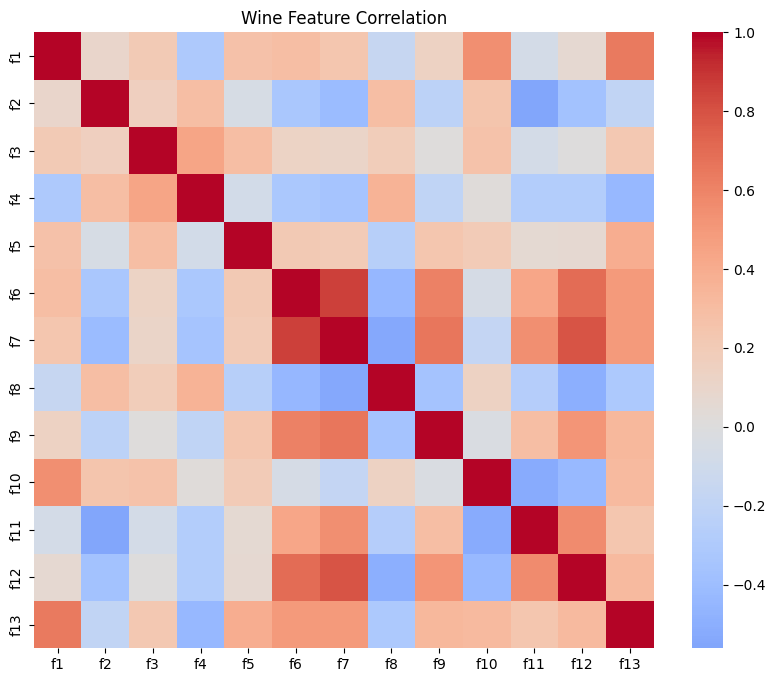


Paper setup confirmation:
Preprocessing: Standardization
Kernel: Inhomogeneous linear kernel


In [18]:
#EDA

wine_df_clean = pd.DataFrame(X_wine_raw, columns=[f"f{i}" for i in range(1, X_wine_raw.shape[1] + 1)])
wine_df_clean["class"] = y_wine_processed

print("Wine EDA Summary")
print("-" * 40)

print("Number of samples:", wine_df_clean.shape[0])
print("Number of features:", wine_df_clean.shape[1] - 1)
print("Number of classes:", wine_df_clean["class"].nunique())

print("\nMissing values:", wine_df_clean.isna().sum().sum())

print("\nClass distribution:")
print(wine_df_clean["class"].value_counts().sort_index())

print("\nFeature summary:")
display(wine_df_clean.drop(columns=["class"]).describe())

plt.figure(figsize=(10, 8))
sns.heatmap(wine_df_clean.drop(columns=["class"]).corr(), cmap="coolwarm", center=0)
plt.title("Wine Feature Correlation")
plt.show()

print("\nPaper setup confirmation:")
print("Preprocessing: Standardization")
print("Kernel: Inhomogeneous linear kernel")

In [21]:
#Deterministic SVM (formulation check)

def inhomogeneous_linear_kernel(X1, X2, c):
    return c + X1 @ X2.T

def stabilize_kernel(K, jitter=1e-8):
    K = 0.5 * (K + K.T)
    K = K + jitter * np.eye(K.shape[0])
    return K

def get_c_parameter(X):
    c_val = np.max(np.std(X, axis=0, ddof=1))
    if np.isnan(c_val) or c_val <= 0:
        c_val = 1.0
    return c_val

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_wine_raw,
    y_wine_processed,
    test_size=0.25,
    stratify=y_wine_processed,
    random_state=42
)

X_train, X_test = preprocess_wine_split(X_train_raw, X_test_raw)

c_kernel = get_c_parameter(X_train)

K = inhomogeneous_linear_kernel(X_train, X_train, c_kernel)
K = stabilize_kernel(K)

classes = np.unique(y_train)
wine_det_models = []

nu_test = 1.0

for cls in classes:

    y_binary = np.where(y_train == cls, 1, -1)
    n = len(y_binary)

    u = cp.Variable(n)
    gamma_var = cp.Variable()
    xi = cp.Variable(n)

    decision = K @ cp.multiply(y_binary, u)

    constraints = [
        cp.multiply(y_binary, decision - gamma_var) >= 1 - xi,
        xi >= 0
    ]

    objective = cp.Minimize(
        cp.norm(u, 1) + nu_test * cp.sum(xi)
    )

    problem = cp.Problem(objective, constraints)
    problem.solve(solver=cp.CLARABEL, verbose=False)

    wine_det_models.append({
        "class": cls,
        "u": np.asarray(u.value).reshape(-1),
        "gamma": float(gamma_var.value),
        "xi": np.asarray(xi.value).reshape(-1),
        "y_binary": y_binary,
        "X_train": X_train,
        "c_kernel": c_kernel,
        "status": problem.status
    })

print("Wine deterministic nonlinear SVM formulation solved successfully.")
print("Kernel used: Inhomogeneous linear")
print("c parameter:", c_kernel)
print("Solver used: CLARABEL")
print("Solver statuses:", [m["status"] for m in wine_det_models])

Wine deterministic nonlinear SVM formulation solved successfully.
Kernel used: Inhomogeneous linear
c parameter: 1.0037807318213268
Solver used: CLARABEL
Solver statuses: ['optimal', 'optimal', 'optimal']


In [24]:
#Deterministic SVM (96-run)

wine_split_settings = {
    "75/25": 0.25,
    "50/50": 0.50,
    "25/75": 0.75
}

N_REPEATS = 96
NMAX = 10**4
nu_values = np.logspace(-3, 0, 5)

def linear_search_b_eq10(K, y_binary, u_val, gamma_val, xi_val):
    omega_pos = np.max(y_binary * xi_val)
    omega_neg = np.max(-y_binary * xi_val)

    lower = gamma_val + 1 - omega_neg
    upper = gamma_val - 1 + omega_pos

    if lower > upper:
        lower, upper = upper, lower

    b_grid = np.linspace(lower, upper, NMAX)

    train_scores_without_b = K @ (y_binary * u_val)

    best_b = None
    best_error_count = np.inf

    for b in b_grid:
        error_count = np.sum(
            (y_binary * b - y_binary * train_scores_without_b) > 0
        )

        if error_count < best_error_count:
            best_error_count = error_count
            best_b = b

    return best_b, best_error_count

def train_deterministic_binary_eq9(X_train, y_binary, nu, c_kernel):
    n = len(y_binary)

    K = inhomogeneous_linear_kernel(X_train, X_train, c_kernel)
    K = stabilize_kernel(K)

    u = cp.Variable(n)
    gamma_var = cp.Variable()
    xi = cp.Variable(n)

    decision = K @ cp.multiply(y_binary, u)

    constraints = [
        cp.multiply(y_binary, decision - gamma_var) >= 1 - xi,
        xi >= 0
    ]

    objective = cp.Minimize(
        cp.norm(u, 1) + nu * cp.sum(xi)
    )

    problem = cp.Problem(objective, constraints)
    problem.solve(solver=cp.CLARABEL, verbose=False)

    if u.value is None or gamma_var.value is None or xi.value is None:
        return None

    u_val = np.asarray(u.value).reshape(-1)
    gamma_val = float(gamma_var.value)
    xi_val = np.asarray(xi.value).reshape(-1)

    b_val, train_error_count = linear_search_b_eq10(
        K=K,
        y_binary=y_binary,
        u_val=u_val,
        gamma_val=gamma_val,
        xi_val=xi_val
    )

    return {
        "u": u_val,
        "gamma": gamma_val,
        "xi": xi_val,
        "b": b_val,
        "train_error_count": train_error_count,
        "y_binary": y_binary,
        "X_train": X_train,
        "c_kernel": c_kernel,
        "nu": nu,
        "status": problem.status
    }

def train_deterministic_ovr_for_nu(X_train, y_train, nu):
    c_kernel = get_c_parameter(X_train)
    classes = np.unique(y_train)

    models = []

    for cls in classes:
        y_binary = np.where(y_train == cls, 1, -1)

        model = train_deterministic_binary_eq9(
            X_train=X_train,
            y_binary=y_binary,
            nu=nu,
            c_kernel=c_kernel
        )

        if model is None:
            return None

        model["class"] = cls
        models.append(model)

    return models

def predict_deterministic_ovr(models, X_test):
    scores = []

    for model in models:
        K_test = inhomogeneous_linear_kernel(
            X_test,
            model["X_train"],
            model["c_kernel"]
        )

        score = K_test @ (model["y_binary"] * model["u"]) - model["b"]
        scores.append(score)

    scores = np.vstack(scores).T
    class_labels = np.array([model["class"] for model in models])

    return class_labels[np.argmax(scores, axis=1)]

def select_best_nu_deterministic(X_train, y_train):
    best_models = None
    best_nu = None
    best_train_error = np.inf

    for nu in nu_values:
        models = train_deterministic_ovr_for_nu(
            X_train=X_train,
            y_train=y_train,
            nu=nu
        )

        if models is None:
            continue

        y_train_pred = predict_deterministic_ovr(models, X_train)
        train_error = np.mean(y_train_pred != y_train)

        if train_error < best_train_error:
            best_train_error = train_error
            best_nu = nu
            best_models = models

    return best_models, best_nu, best_train_error

wine_det_results = []
wine_det_failed_runs = []

for split_name, test_size in wine_split_settings.items():

    split_metrics = []
    failed_solver_runs = 0

    for seed in tqdm(range(N_REPEATS), desc=f"Wine deterministic SVM - {split_name}"):

        X_train_raw, X_test_raw, y_train, y_test = train_test_split(
            X_wine_raw,
            y_wine_processed,
            test_size=test_size,
            stratify=y_wine_processed,
            random_state=seed
        )

        X_train, X_test = preprocess_wine_split(X_train_raw, X_test_raw)

        models, best_nu, train_error = select_best_nu_deterministic(
            X_train=X_train,
            y_train=y_train
        )

        if models is None:
            failed_solver_runs += 1
            wine_det_failed_runs.append({
                "Split": split_name,
                "Seed": seed
            })
            continue

        y_pred = predict_deterministic_ovr(models, X_test)

        split_metrics.append({
            "accuracy": accuracy_score(y_test, y_pred),
            "precision_macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
            "recall_macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
            "f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
            "best_nu": best_nu,
            "training_error": train_error
        })

    split_metrics_df = pd.DataFrame(split_metrics)

    wine_det_results.append({
        "Dataset": "Wine",
        "Model": "Deterministic nonlinear kernel SVM",
        "Split": split_name,
        "Preprocessing": "Standardization",
        "Kernel": "Inhomogeneous linear",
        "Solver": "CLARABEL",
        "Nmax": NMAX,
        "Valid Runs": len(split_metrics),
        "Failed Solver Runs": failed_solver_runs,
        "Most Common nu": split_metrics_df["best_nu"].mode().iloc[0] if len(split_metrics_df) > 0 else np.nan,
        "Accuracy Mean": split_metrics_df["accuracy"].mean() if len(split_metrics_df) > 0 else np.nan,
        "Accuracy Std": split_metrics_df["accuracy"].std() if len(split_metrics_df) > 0 else np.nan,
        "Precision Mean": split_metrics_df["precision_macro"].mean() if len(split_metrics_df) > 0 else np.nan,
        "Recall Mean": split_metrics_df["recall_macro"].mean() if len(split_metrics_df) > 0 else np.nan,
        "F1 Mean": split_metrics_df["f1_macro"].mean() if len(split_metrics_df) > 0 else np.nan
    })

wine_det_results_df = pd.DataFrame(wine_det_results)

print("Wine Deterministic Nonlinear Kernel SVM Results (96-run average):")
display(wine_det_results_df)

Wine deterministic SVM - 25/75: 100%|██████████| 96/96 [00:51<00:00,  1.85it/s]

Wine Deterministic Nonlinear Kernel SVM Results (96-run average):


,Dataset,Model,Split,Preprocessing,Kernel,Solver,Nmax,Valid Runs,Failed Solver Runs,Most Common nu,Accuracy Mean,Accuracy Std,Precision Mean,Recall Mean,F1 Mean
0,Wine,Deterministic nonlinear kernel SVM,75/25,Standardization,Inhomogeneous linear,CLARABEL,10000,96,0,1.000000,0.975926,0.022951,0.977425,0.977488,0.976410
1,Wine,Deterministic nonlinear kernel SVM,50/50,Standardization,Inhomogeneous linear,CLARABEL,10000,96,0,0.177828,0.967697,0.017349,0.967737,0.970519,0.968130
2,Wine,Deterministic nonlinear kernel SVM,25/75,Standardization,Inhomogeneous linear,CLARABEL,10000,96,0,0.177828,0.951259,0.022660,0.951916,0.956320,0.952203


In [36]:
# Robust SVM (formulation check)

def compute_C_np(n_features, p_norm):
    if p_norm <= 2:
        return 1.0
    elif p_norm == np.inf:
        return np.sqrt(n_features)
    else:
        return n_features ** ((p_norm - 2) / (2 * p_norm))

def compute_delta_linear(eta, n_features, p_norm):
    C_np = compute_C_np(n_features, p_norm)
    return C_np * eta

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_wine_raw,
    y_wine_processed,
    test_size=0.25,
    stratify=y_wine_processed,
    random_state=42
)

X_train, X_test = preprocess_wine_split(X_train_raw, X_test_raw)

n_samples, n_features = X_train.shape

c_kernel = get_c_parameter(X_train)

K = inhomogeneous_linear_kernel(X_train, X_train, c_kernel)
K = stabilize_kernel(K)

K_diag_sqrt = np.sqrt(np.diag(K))

rho = 1e-3
p_norm = 1
nu = 1.0

classes = np.unique(y_train)
wine_robust_models = []

for cls in classes:

    y_binary = np.where(y_train == cls, 1, -1)

    class_pos = X_train[y_binary == 1]
    class_neg = X_train[y_binary == -1]

    eta_pos = rho * np.max(np.std(class_pos, axis=0, ddof=1))
    eta_neg = rho * np.max(np.std(class_neg, axis=0, ddof=1))

    if np.isnan(eta_pos):
        eta_pos = 0.0
    if np.isnan(eta_neg):
        eta_neg = 0.0

    eta = np.where(y_binary == 1, eta_pos, eta_neg)
    delta = compute_delta_linear(eta, n_features, p_norm)

    u = cp.Variable(n_samples)
    gamma_var = cp.Variable()
    xi = cp.Variable(n_samples)
    s = cp.Variable(n_samples)

    constraints = [
        s >= u,
        s >= -u,
        xi >= 0
    ]

    uncertainty_norm = cp.sum(cp.multiply(K_diag_sqrt, s))

    for i in range(n_samples):
        margin_term = y_binary[i] * cp.sum(
            cp.multiply(K[i, :], cp.multiply(y_binary, u))
        )

        constraints.append(
            margin_term - delta[i] * uncertainty_norm >= 1 - xi[i] + y_binary[i] * gamma_var
        )

    objective = cp.Minimize(
        cp.norm(u, 1) + nu * cp.sum(xi)
    )

    problem = cp.Problem(objective, constraints)
    problem.solve(solver=cp.CLARABEL, verbose=False)

    wine_robust_models.append({
        "class": cls,
        "u": np.asarray(u.value).reshape(-1),
        "gamma": float(gamma_var.value),
        "xi": np.asarray(xi.value).reshape(-1),
        "y_binary": y_binary,
        "X_train": X_train,
        "c_kernel": c_kernel,
        "delta": delta,
        "rho": rho,
        "p_norm": p_norm,
        "nu": nu,
        "status": problem.status
    })

print("Wine robust nonlinear SVM formulation solved successfully.")

Wine robust nonlinear SVM formulation solved successfully.


In [30]:
#Robust SVM (pilot hyperparameter search + 96-run)
#Reduced hyperparameter search due to computational cost.

rho_values = np.logspace(-7, -1, 7)
p_norm_values = [1, 2, np.inf]

ROBUST_PILOT_SEEDS = [0, 1, 2]

def run_robust_pilot_for_split(test_size):
    pilot_results = []
    pilot_failures = []

    for nu in nu_values:
        for rho in rho_values:
            for p_norm in p_norm_values:

                pilot_metrics = []
                failed = False

                for seed in ROBUST_PILOT_SEEDS:
                    X_train_raw, X_test_raw, y_train, y_test = train_test_split(
                        X_wine_raw,
                        y_wine_processed,
                        test_size=test_size,
                        stratify=y_wine_processed,
                        random_state=seed
                    )

                    X_train, X_test = preprocess_wine_split(X_train_raw, X_test_raw)

                    models, errors = train_robust_ovr_fixed_params(
                        X_train=X_train,
                        y_train=y_train,
                        nu=nu,
                        rho=rho,
                        p_norm=p_norm
                    )

                    if models is None:
                        failed = True
                        pilot_failures.extend(errors)
                        break

                    y_pred = predict_robust_ovr(models, X_test)

                    pilot_metrics.append({
                        "accuracy": accuracy_score(y_test, y_pred),
                        "f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0)
                    })

                if failed or len(pilot_metrics) == 0:
                    continue

                pilot_metrics_df = pd.DataFrame(pilot_metrics)

                pilot_results.append({
                    "nu": nu,
                    "rho": rho,
                    "p_norm": p_norm,
                    "p_label": "inf" if p_norm == np.inf else p_norm,
                    "Pilot Accuracy Mean": pilot_metrics_df["accuracy"].mean(),
                    "Pilot F1 Mean": pilot_metrics_df["f1_macro"].mean()
                })

    pilot_results_df = pd.DataFrame(pilot_results)

    if len(pilot_results_df) == 0:
        raise RuntimeError("All robust pilot candidates failed with CLARABEL. Stop before fallback solver.")

    pilot_results_df = pilot_results_df.sort_values(
        by=["Pilot Accuracy Mean", "Pilot F1 Mean"],
        ascending=False
    ).reset_index(drop=True)

    best_nu = pilot_results_df.loc[0, "nu"]
    best_rho = pilot_results_df.loc[0, "rho"]
    best_p = pilot_results_df.loc[0, "p_norm"]

    return best_nu, best_rho, best_p, pilot_results_df, pilot_failures


wine_robust_split_selected_params = {}
wine_robust_pilot_tables = {}

for split_name, test_size in wine_split_settings.items():

    best_nu, best_rho, best_p, pilot_table, pilot_failures = run_robust_pilot_for_split(
        test_size=test_size
    )

    wine_robust_split_selected_params[split_name] = {
        "nu": best_nu,
        "rho": best_rho,
        "p_norm": best_p
    }

    wine_robust_pilot_tables[split_name] = pilot_table

    print(f"\nWine robust pilot search completed for split {split_name}.")
    print("Deviation note: Exact formulation with reduced hyperparameter search due to computational cost.")
    print("Selected nu:", best_nu)
    print("Selected rho:", best_rho)
    print("Selected p:", "inf" if best_p == np.inf else best_p)
    print("Top pilot candidates:")
    display(pilot_table.head(10))


wine_robust_results = []
wine_robust_failed_runs = []

for split_name, test_size in wine_split_settings.items():

    selected = wine_robust_split_selected_params[split_name]
    best_robust_nu = selected["nu"]
    best_robust_rho = selected["rho"]
    best_robust_p = selected["p_norm"]

    split_metrics = []
    failed_solver_runs = 0

    for seed in tqdm(range(N_REPEATS), desc=f"Wine robust SVM fixed params - {split_name}"):

        X_train_raw, X_test_raw, y_train, y_test = train_test_split(
            X_wine_raw,
            y_wine_processed,
            test_size=test_size,
            stratify=y_wine_processed,
            random_state=seed
        )

        X_train, X_test = preprocess_wine_split(X_train_raw, X_test_raw)

        models, errors = train_robust_ovr_fixed_params(
            X_train=X_train,
            y_train=y_train,
            nu=best_robust_nu,
            rho=best_robust_rho,
            p_norm=best_robust_p
        )

        if models is None:
            failed_solver_runs += 1
            wine_robust_failed_runs.append({
                "Split": split_name,
                "Seed": seed,
                "Errors": errors
            })
            continue

        y_pred = predict_robust_ovr(models, X_test)

        split_metrics.append({
            "accuracy": accuracy_score(y_test, y_pred),
            "precision_macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
            "recall_macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
            "f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0)
        })

    split_metrics_df = pd.DataFrame(split_metrics)

    wine_robust_results.append({
        "Dataset": "Wine",
        "Model": "Robust nonlinear kernel SVM",
        "Search Note": "Exact formulation with reduced hyperparameter search due to computational cost",
        "Split": split_name,
        "Preprocessing": "Standardization",
        "Kernel": "Inhomogeneous linear",
        "Solver": "CLARABEL",
        "Nmax": NMAX,
        "Selected nu": best_robust_nu,
        "Selected rho": best_robust_rho,
        "Selected p": "inf" if best_robust_p == np.inf else best_robust_p,
        "Valid Runs": len(split_metrics),
        "Failed Solver Runs": failed_solver_runs,
        "Accuracy Mean": split_metrics_df["accuracy"].mean() if len(split_metrics_df) > 0 else np.nan,
        "Accuracy Std": split_metrics_df["accuracy"].std() if len(split_metrics_df) > 0 else np.nan,
        "Precision Mean": split_metrics_df["precision_macro"].mean() if len(split_metrics_df) > 0 else np.nan,
        "Recall Mean": split_metrics_df["recall_macro"].mean() if len(split_metrics_df) > 0 else np.nan,
        "F1 Mean": split_metrics_df["f1_macro"].mean() if len(split_metrics_df) > 0 else np.nan
    })

wine_robust_results_df = pd.DataFrame(wine_robust_results)

print("Wine Robust Nonlinear Kernel SVM Results (96-run fixed selected configuration by split):")
display(wine_robust_results_df)

if len(wine_robust_failed_runs) > 0:
    print("\nSome robust fixed-configuration runs failed with CLARABEL:")
    display(pd.DataFrame(wine_robust_failed_runs))


Wine robust pilot search completed for split 75/25.
Deviation note: Exact formulation with reduced hyperparameter search due to computational cost.
Selected nu: 0.005623413251903491
Selected rho: 0.01
Selected p: inf
Top pilot candidates:


,nu,rho,p_norm,p_label,Pilot Accuracy Mean,Pilot F1 Mean
0,0.005623,1.000000e-02,inf,inf,0.985185,0.986482
1,1.000000,1.000000e-02,inf,inf,0.985185,0.986482
2,1.000000,1.000000e-01,1.0,1,0.985185,0.986482
3,1.000000,1.000000e-01,2.0,2,0.985185,0.986482
4,1.000000,1.000000e-01,inf,inf,0.985185,0.986482
5,1.000000,1.000000e-07,1.0,1,0.985185,0.985622
6,1.000000,1.000000e-07,2.0,2,0.985185,0.985622
7,1.000000,1.000000e-07,inf,inf,0.985185,0.985622
8,1.000000,1.000000e-06,1.0,1,0.985185,0.985622
9,1.000000,1.000000e-06,2.0,2,0.985185,0.985622



Wine robust pilot search completed for split 50/50.
Deviation note: Exact formulation with reduced hyperparameter search due to computational cost.
Selected nu: 0.1778279410038923
Selected rho: 1e-07
Selected p: 1.0
Top pilot candidates:


,nu,rho,p_norm,p_label,Pilot Accuracy Mean,Pilot F1 Mean
0,0.177828,1.000000e-07,1.0,1,0.981273,0.982359
1,0.177828,1.000000e-07,2.0,2,0.981273,0.982359
2,0.177828,1.000000e-07,inf,inf,0.981273,0.982359
3,0.177828,1.000000e-06,1.0,1,0.981273,0.982359
4,0.177828,1.000000e-06,2.0,2,0.981273,0.982359
5,0.177828,1.000000e-06,inf,inf,0.981273,0.982359
6,0.177828,1.000000e-05,1.0,1,0.981273,0.982359
7,0.177828,1.000000e-05,2.0,2,0.981273,0.982359
8,0.177828,1.000000e-05,inf,inf,0.981273,0.982359
9,0.177828,1.000000e-04,1.0,1,0.981273,0.982359



Wine robust pilot search completed for split 25/75.
Deviation note: Exact formulation with reduced hyperparameter search due to computational cost.
Selected nu: 0.1778279410038923
Selected rho: 0.1
Selected p: inf
Top pilot candidates:


,nu,rho,p_norm,p_label,Pilot Accuracy Mean,Pilot F1 Mean
0,0.177828,1.000000e-01,inf,inf,0.965174,0.967025
1,1.000000,1.000000e-01,1.0,1,0.962687,0.963101
2,1.000000,1.000000e-01,2.0,2,0.962687,0.963101
3,1.000000,1.000000e-02,1.0,1,0.962687,0.963082
4,1.000000,1.000000e-02,2.0,2,0.962687,0.963082
5,1.000000,1.000000e-02,inf,inf,0.962687,0.963082
6,0.177828,1.000000e-01,1.0,1,0.960199,0.961017
7,0.177828,1.000000e-01,2.0,2,0.960199,0.961017
8,1.000000,1.000000e-07,1.0,1,0.957711,0.958428
9,1.000000,1.000000e-07,2.0,2,0.957711,0.958428


Wine robust SVM fixed params - 25/75: 100%|██████████| 96/96 [00:14<00:00,  6.81it/s]

Wine Robust Nonlinear Kernel SVM Results (96-run fixed selected configuration by split):


,Dataset,Model,Search Note,Split,Preprocessing,Kernel,Solver,Nmax,Selected nu,Selected rho,Selected p,Valid Runs,Failed Solver Runs,Accuracy Mean,Accuracy Std,Precision Mean,Recall Mean,F1 Mean
0,Wine,Robust nonlinear kernel SVM,Exact formulation with reduced hyperparameter ...,75/25,Standardization,Inhomogeneous linear,CLARABEL,10000,0.005623,1.000000e-02,inf,96,0,0.961111,0.025995,0.961484,0.967014,0.962144
1,Wine,Robust nonlinear kernel SVM,Exact formulation with reduced hyperparameter ...,50/50,Standardization,Inhomogeneous linear,CLARABEL,10000,0.177828,1.000000e-07,1.0,96,0,0.965473,0.018099,0.965686,0.969196,0.966110
2,Wine,Robust nonlinear kernel SVM,Exact formulation with reduced hyperparameter ...,25/75,Standardization,Inhomogeneous linear,CLARABEL,10000,0.177828,1.000000e-01,inf,96,0,0.946440,0.022970,0.947037,0.953400,0.947715


# Dataset-Parkinsons (Binary Classification, Medical Data)

In [35]:
#Importing dataset

parkinsons_url = "https://raw.githubusercontent.com/husseinareefurrahman-collab/ISE521-Term-Paper/refs/heads/main/parkinsons.data"

parkinsons_df = pd.read_csv(parkinsons_url)

X_parkinsons = parkinsons_df.drop(columns=["name", "status"]).values
y_parkinsons = parkinsons_df["status"].values

print("Parkinsons dataset loaded successfully.")
print("Shape:", X_parkinsons.shape)
print("Classes:", np.unique(y_parkinsons))

Parkinsons dataset loaded successfully.
Shape: (195, 22)
Classes: [0 1]


In [32]:
#Preprocessing

from sklearn.preprocessing import MinMaxScaler

X_parkinsons_raw = X_parkinsons.copy()
y_parkinsons_processed = y_parkinsons.copy()

def preprocess_parkinsons_split(X_train, X_test):
    scaler = MinMaxScaler()
    X_train_processed = scaler.fit_transform(X_train)
    X_test_processed = scaler.transform(X_test)

    return X_train_processed, X_test_processed

print("Parkinsons preprocessing defined successfully.")
print("\nMissing values in features:", np.isnan(X_parkinsons_raw).sum())
print("Missing values in target:", np.isnan(y_parkinsons_processed).sum())

Parkinsons preprocessing defined successfully.

Missing values in features: 0
Missing values in target: 0


Parkinsons EDA Summary
----------------------------------------
Number of samples: 195
Number of features: 22
Number of classes: 2

Class distribution:
class
0     48
1    147
Name: count, dtype: int64

Feature summary:


,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,...,f13,f14,f15,f16,f17,f18,f19,f20,f21,f22
count,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,...,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000,195.000000
mean,154.228641,197.104918,116.324631,0.006220,0.000044,0.003306,0.003446,0.009920,0.029709,0.282251,...,0.024081,0.046993,0.024847,21.885974,0.498536,0.718099,-5.684397,0.226510,2.381826,0.206552
std,41.390065,91.491548,43.521413,0.004848,0.000035,0.002968,0.002759,0.008903,0.018857,0.194877,...,0.016947,0.030459,0.040418,4.425764,0.103942,0.055336,1.090208,0.083406,0.382799,0.090119
min,88.333000,102.145000,65.476000,0.001680,0.000007,0.000680,0.000920,0.002040,0.009540,0.085000,...,0.007190,0.013640,0.000650,8.441000,0.256570,0.574282,-7.964984,0.006274,1.423287,0.044539
25%,117.572000,134.862500,84.291000,0.003460,0.000020,0.001660,0.001860,0.004985,0.016505,0.148500,...,0.013080,0.024735,0.005925,19.198000,0.421306,0.674758,-6.450096,0.174351,2.099125,0.137451
50%,148.790000,175.829000,104.315000,0.004940,0.000030,0.002500,0.002690,0.007490,0.022970,0.221000,...,0.018260,0.038360,0.011660,22.085000,0.495954,0.722254,-5.720868,0.218885,2.361532,0.194052
75%,182.769000,224.205500,140.018500,0.007365,0.000060,0.003835,0.003955,0.011505,0.037885,0.350000,...,0.029400,0.060795,0.025640,25.075500,0.587562,0.761881,-5.046192,0.279234,2.636456,0.252980
max,260.105000,592.030000,239.170000,0.033160,0.000260,0.021440,0.019580,0.064330,0.119080,1.302000,...,0.137780,0.169420,0.314820,33.047000,0.685151,0.825288,-2.434031,0.450493,3.671155,0.527367


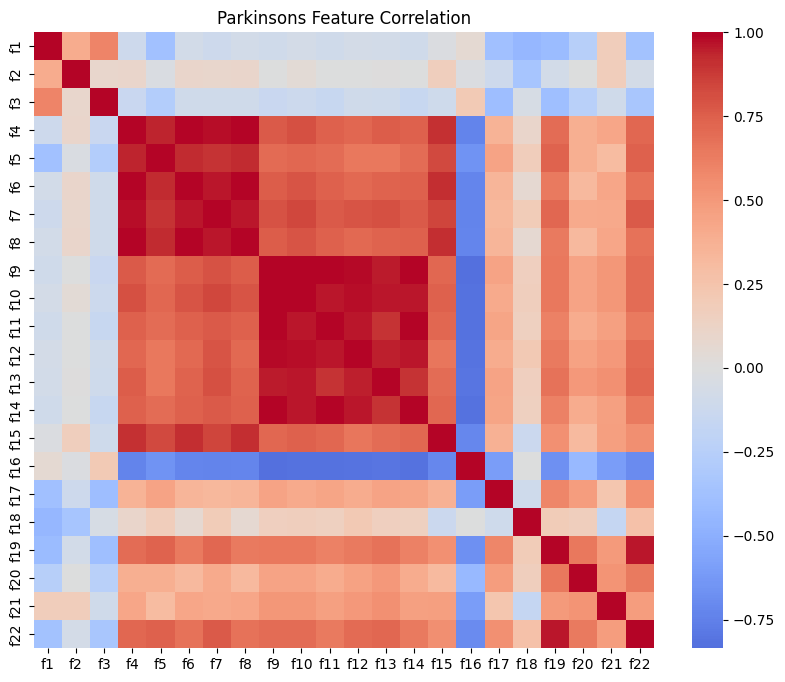

In [33]:
#EDA

parkinsons_df_clean = pd.DataFrame(
    X_parkinsons_raw,
    columns=[f"f{i}" for i in range(1, X_parkinsons_raw.shape[1] + 1)]
)
parkinsons_df_clean["class"] = y_parkinsons_processed

print("Parkinsons EDA Summary")
print("-" * 40)

print("Number of samples:", parkinsons_df_clean.shape[0])
print("Number of features:", parkinsons_df_clean.shape[1] - 1)
print("Number of classes:", parkinsons_df_clean["class"].nunique())

print("\nClass distribution:")
print(parkinsons_df_clean["class"].value_counts().sort_index())

print("\nFeature summary:")
display(parkinsons_df_clean.drop(columns=["class"]).describe())

plt.figure(figsize=(10, 8))
sns.heatmap(parkinsons_df_clean.drop(columns=["class"]).corr(), cmap="coolwarm", center=0)
plt.title("Parkinsons Feature Correlation")
plt.show()

In [34]:
#Deterministic SVM (formulation check)

def homogeneous_linear_kernel(X1, X2):
    return X1 @ X2.T

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_parkinsons_raw,
    y_parkinsons_processed,
    test_size=0.25,
    stratify=y_parkinsons_processed,
    random_state=42
)

X_train, X_test = preprocess_parkinsons_split(X_train_raw, X_test_raw)

K = homogeneous_linear_kernel(X_train, X_train)
K = stabilize_kernel(K)

classes = np.unique(y_train)
parkinsons_det_models = []

nu_test = 1.0

for cls in classes:

    y_binary = np.where(y_train == cls, 1, -1)
    n = len(y_binary)

    u = cp.Variable(n)
    gamma_var = cp.Variable()
    xi = cp.Variable(n)

    decision = K @ cp.multiply(y_binary, u)

    constraints = [
        cp.multiply(y_binary, decision - gamma_var) >= 1 - xi,
        xi >= 0
    ]

    objective = cp.Minimize(
        cp.norm(u, 1) + nu_test * cp.sum(xi)
    )

    problem = cp.Problem(objective, constraints)
    problem.solve(solver=cp.CLARABEL, verbose=False)

    parkinsons_det_models.append({
        "class": cls,
        "u": np.asarray(u.value).reshape(-1),
        "gamma": float(gamma_var.value),
        "xi": np.asarray(xi.value).reshape(-1),
        "y_binary": y_binary,
        "X_train": X_train,
        "status": problem.status
    })

print("Parkinsons deterministic nonlinear SVM formulation solved successfully.")

Parkinsons deterministic nonlinear SVM formulation solved successfully.


In [38]:
#Deterministic SVM (96-run)

ACCEPTABLE_STATUSES = ["optimal", "optimal_inaccurate"]

def train_parkinsons_deterministic_binary_eq9(X_train, y_binary, nu):
    n = len(y_binary)

    K = homogeneous_linear_kernel(X_train, X_train)
    K = stabilize_kernel(K)

    u = cp.Variable(n)
    gamma_var = cp.Variable()
    xi = cp.Variable(n)

    decision = K @ cp.multiply(y_binary, u)

    constraints = [
        cp.multiply(y_binary, decision - gamma_var) >= 1 - xi,
        xi >= 0
    ]

    objective = cp.Minimize(
        cp.norm(u, 1) + nu * cp.sum(xi)
    )

    problem = cp.Problem(objective, constraints)
    problem.solve(solver=cp.CLARABEL, verbose=False)

    if problem.status not in ACCEPTABLE_STATUSES:
        return None

    if u.value is None or gamma_var.value is None or xi.value is None:
        return None

    u_val = np.asarray(u.value).reshape(-1)
    gamma_val = float(gamma_var.value)
    xi_val = np.asarray(xi.value).reshape(-1)

    b_val, train_error_count = linear_search_b_eq10(
        K=K,
        y_binary=y_binary,
        u_val=u_val,
        gamma_val=gamma_val,
        xi_val=xi_val
    )

    return {
        "u": u_val,
        "gamma": gamma_val,
        "xi": xi_val,
        "b": b_val,
        "train_error_count": train_error_count,
        "y_binary": y_binary,
        "X_train": X_train,
        "nu": nu,
        "status": problem.status
    }

def train_parkinsons_deterministic_ovr_for_nu(X_train, y_train, nu):
    classes = np.unique(y_train)
    models = []

    for cls in classes:
        y_binary = np.where(y_train == cls, 1, -1)

        model = train_parkinsons_deterministic_binary_eq9(
            X_train=X_train,
            y_binary=y_binary,
            nu=nu
        )

        if model is None:
            return None

        model["class"] = cls
        models.append(model)

    return models

def select_best_nu_parkinsons_deterministic(X_train, y_train):
    best_models = None
    best_nu = None
    best_train_error = np.inf

    for nu in nu_values:
        models = train_parkinsons_deterministic_ovr_for_nu(
            X_train=X_train,
            y_train=y_train,
            nu=nu
        )

        if models is None:
            continue

        y_train_pred = predict_parkinsons_deterministic_ovr(models, X_train)
        train_error = np.mean(y_train_pred != y_train)

        if train_error < best_train_error:
            best_train_error = train_error
            best_nu = nu
            best_models = models

    return best_models, best_nu, best_train_error

parkinsons_det_results = []
parkinsons_det_failed_runs = []

for split_name, test_size in parkinsons_split_settings.items():

    split_metrics = []
    failed_solver_runs = 0
    optimal_runs = 0
    optimal_inaccurate_runs = 0

    for seed in tqdm(range(N_REPEATS), desc=f"Parkinsons deterministic SVM - {split_name}"):

        X_train_raw, X_test_raw, y_train, y_test = train_test_split(
            X_parkinsons_raw,
            y_parkinsons_processed,
            test_size=test_size,
            stratify=y_parkinsons_processed,
            random_state=seed
        )

        X_train, X_test = preprocess_parkinsons_split(X_train_raw, X_test_raw)

        models, best_nu, train_error = select_best_nu_parkinsons_deterministic(
            X_train=X_train,
            y_train=y_train
        )

        if models is None:
            failed_solver_runs += 1
            parkinsons_det_failed_runs.append({
                "Split": split_name,
                "Seed": seed
            })
            continue

        model_statuses = [m["status"] for m in models]

        if all(status == "optimal" for status in model_statuses):
            optimal_runs += 1
        elif any(status == "optimal_inaccurate" for status in model_statuses):
            optimal_inaccurate_runs += 1

        y_pred = predict_parkinsons_deterministic_ovr(models, X_test)

        split_metrics.append({
            "accuracy": accuracy_score(y_test, y_pred),
            "precision_macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
            "recall_macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
            "f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
            "best_nu": best_nu,
            "training_error": train_error,
            "statuses": model_statuses
        })

    split_metrics_df = pd.DataFrame(split_metrics)

    parkinsons_det_results.append({
        "Dataset": "Parkinsons",
        "Model": "Deterministic nonlinear kernel SVM",
        "Split": split_name,
        "Preprocessing": "Min-max normalization",
        "Kernel": "Homogeneous linear",
        "Solver": "CLARABEL",
        "Nmax": NMAX,
        "Valid Runs": len(split_metrics),
        "Optimal Runs": optimal_runs,
        "Optimal Inaccurate Runs": optimal_inaccurate_runs,
        "Failed Solver Runs": failed_solver_runs,
        "Most Common nu": split_metrics_df["best_nu"].mode().iloc[0] if len(split_metrics_df) > 0 else np.nan,
        "Accuracy Mean": split_metrics_df["accuracy"].mean() if len(split_metrics_df) > 0 else np.nan,
        "Accuracy Std": split_metrics_df["accuracy"].std() if len(split_metrics_df) > 0 else np.nan,
        "Precision Mean": split_metrics_df["precision_macro"].mean() if len(split_metrics_df) > 0 else np.nan,
        "Recall Mean": split_metrics_df["recall_macro"].mean() if len(split_metrics_df) > 0 else np.nan,
        "F1 Mean": split_metrics_df["f1_macro"].mean() if len(split_metrics_df) > 0 else np.nan
    })

parkinsons_det_results_df = pd.DataFrame(parkinsons_det_results)

print("Parkinsons Deterministic Nonlinear Kernel SVM Results (96-run average):")
display(parkinsons_det_results_df)

print(
    "\nNote: Some CLARABEL solutions were returned as optimal_inaccurate; "
    "results are retained but flagged."
)

Parkinsons deterministic SVM - 25/75:   8%|▊         | 8/96 [00:00<00:06, 13.24it/s]C:\Users\husse\AppData\Local\Temp\ipykernel_26660\2139241453.py:27: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  problem.solve(solver=cp.CLARABEL, verbose=False)
Parkinsons deterministic SVM - 25/75:  31%|███▏      | 30/96 [00:02<00:04, 13.31it/s]C:\Users\husse\AppData\Local\Temp\ipykernel_26660\2139241453.py:27: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  problem.solve(solver=cp.CLARABEL, verbose=False)
Parkinsons deterministic SVM - 25/75:  38%|███▊      | 36/96 [00:02<00:04, 13.37it/s]C:\Users\husse\AppData\Local\Temp\ipykernel_26660\2139241453.py:27: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  problem.solve(s

Parkinsons Deterministic Nonlinear Kernel SVM Results (96-run average):


,Dataset,Model,Split,Preprocessing,Kernel,Solver,Nmax,Valid Runs,Optimal Runs,Optimal Inaccurate Runs,Failed Solver Runs,Most Common nu,Accuracy Mean,Accuracy Std,Precision Mean,Recall Mean,F1 Mean
0,Parkinsons,Deterministic nonlinear kernel SVM,75/25,Min-max normalization,Homogeneous linear,CLARABEL,10000,96,96,0,0,1.0,0.857143,0.042086,0.885561,0.735607,0.765919
1,Parkinsons,Deterministic nonlinear kernel SVM,50/50,Min-max normalization,Homogeneous linear,CLARABEL,10000,96,96,0,0,1.0,0.834609,0.044018,0.842735,0.722298,0.743722
2,Parkinsons,Deterministic nonlinear kernel SVM,25/75,Min-max normalization,Homogeneous linear,CLARABEL,10000,96,96,0,0,1.0,0.821003,0.034593,0.815908,0.707766,0.721309



Note: Some CLARABEL solutions were returned as optimal_inaccurate; results are retained but flagged.


In [39]:
#Robust SVM (formulation check)

def compute_delta_homogeneous_linear(eta, n_features, p_norm):
    C_np = compute_C_np(n_features, p_norm)
    return C_np * eta

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_parkinsons_raw,
    y_parkinsons_processed,
    test_size=0.25,
    stratify=y_parkinsons_processed,
    random_state=42
)

X_train, X_test = preprocess_parkinsons_split(X_train_raw, X_test_raw)

n_samples, n_features = X_train.shape

K = homogeneous_linear_kernel(X_train, X_train)
K = stabilize_kernel(K)

K_diag_sqrt = np.sqrt(np.maximum(np.diag(K), 0))

rho = 1e-3
p_norm = 1
nu = 1.0

classes = np.unique(y_train)
parkinsons_robust_models = []

for cls in classes:

    y_binary = np.where(y_train == cls, 1, -1)

    class_pos = X_train[y_binary == 1]
    class_neg = X_train[y_binary == -1]

    eta_pos = rho * np.max(np.std(class_pos, axis=0, ddof=1))
    eta_neg = rho * np.max(np.std(class_neg, axis=0, ddof=1))

    if np.isnan(eta_pos):
        eta_pos = 0.0
    if np.isnan(eta_neg):
        eta_neg = 0.0

    eta = np.where(y_binary == 1, eta_pos, eta_neg)
    delta = compute_delta_homogeneous_linear(eta, n_features, p_norm)

    u = cp.Variable(n_samples)
    gamma_var = cp.Variable()
    xi = cp.Variable(n_samples)
    s = cp.Variable(n_samples)

    constraints = [
        s >= u,
        s >= -u,
        xi >= 0
    ]

    uncertainty_norm = cp.sum(cp.multiply(K_diag_sqrt, s))

    for i in range(n_samples):
        margin_term = y_binary[i] * cp.sum(
            cp.multiply(K[i, :], cp.multiply(y_binary, u))
        )

        constraints.append(
            margin_term - delta[i] * uncertainty_norm >= 1 - xi[i] + y_binary[i] * gamma_var
        )

    objective = cp.Minimize(
        cp.norm(u, 1) + nu * cp.sum(xi)
    )

    problem = cp.Problem(objective, constraints)
    problem.solve(solver=cp.CLARABEL, verbose=False)

    parkinsons_robust_models.append({
        "class": cls,
        "u": np.asarray(u.value).reshape(-1),
        "gamma": float(gamma_var.value),
        "xi": np.asarray(xi.value).reshape(-1),
        "y_binary": y_binary,
        "X_train": X_train,
        "delta": delta,
        "rho": rho,
        "p_norm": p_norm,
        "nu": nu,
        "status": problem.status
    })

print("Parkinsons robust nonlinear SVM formulation solved successfully.")

Parkinsons robust nonlinear SVM formulation solved successfully.


In [40]:
#Robust SVM (pilot hyperparameter search + 96-run)

rho_values = np.logspace(-7, -1, 7)
p_norm_values = [1, 2, np.inf]
ROBUST_PILOT_SEEDS = [0, 1, 2]
ACCEPTABLE_STATUSES = ["optimal", "optimal_inaccurate"]

def linear_search_b_parkinsons_robust_eq28(K, y_binary, u_val, gamma_val, xi_val, delta):
    omega_pos = np.max(y_binary * xi_val)
    omega_neg = np.max(-y_binary * xi_val)

    lower = gamma_val + 1 - omega_neg
    upper = gamma_val - 1 + omega_pos

    if lower > upper:
        lower, upper = upper, lower

    b_grid = np.linspace(lower, upper, NMAX)

    train_scores_without_b = K @ (y_binary * u_val)
    uncertainty_score = delta * np.sum(np.sqrt(np.maximum(np.diag(K), 0)) * np.abs(u_val))

    values = (
        y_binary.reshape(1, -1) * b_grid.reshape(-1, 1)
        - y_binary.reshape(1, -1) * train_scores_without_b.reshape(1, -1)
        + uncertainty_score.reshape(1, -1)
    )

    error_counts = np.sum(values > 0, axis=1)

    best_idx = np.argmin(error_counts)
    return b_grid[best_idx], error_counts[best_idx]

def train_parkinsons_robust_binary_eq27(X_train, y_binary, nu, rho, p_norm):
    n_samples, n_features = X_train.shape

    K = homogeneous_linear_kernel(X_train, X_train)
    K = stabilize_kernel(K)

    K_diag_sqrt = np.sqrt(np.maximum(np.diag(K), 0))

    class_pos = X_train[y_binary == 1]
    class_neg = X_train[y_binary == -1]

    eta_pos = rho * np.max(np.std(class_pos, axis=0, ddof=1))
    eta_neg = rho * np.max(np.std(class_neg, axis=0, ddof=1))

    if np.isnan(eta_pos):
        eta_pos = 0.0
    if np.isnan(eta_neg):
        eta_neg = 0.0

    eta = np.where(y_binary == 1, eta_pos, eta_neg)
    delta = compute_delta_homogeneous_linear(eta, n_features, p_norm)

    u = cp.Variable(n_samples)
    gamma_var = cp.Variable()
    xi = cp.Variable(n_samples)
    s = cp.Variable(n_samples)

    constraints = [
        s >= u,
        s >= -u,
        xi >= 0
    ]

    uncertainty_norm = cp.sum(cp.multiply(K_diag_sqrt, s))

    for i in range(n_samples):
        margin_term = y_binary[i] * cp.sum(
            cp.multiply(K[i, :], cp.multiply(y_binary, u))
        )

        constraints.append(
            margin_term - delta[i] * uncertainty_norm >= 1 - xi[i] + y_binary[i] * gamma_var
        )

    objective = cp.Minimize(
        cp.norm(u, 1) + nu * cp.sum(xi)
    )

    problem = cp.Problem(objective, constraints)

    try:
        problem.solve(solver=cp.CLARABEL, verbose=False)
    except Exception as e:
        return None, str(e)

    if problem.status not in ACCEPTABLE_STATUSES:
        return None, f"Status={problem.status}"

    if u.value is None or gamma_var.value is None or xi.value is None:
        return None, f"Status={problem.status}, missing variable value"

    u_val = np.asarray(u.value).reshape(-1)
    gamma_val = float(gamma_var.value)
    xi_val = np.asarray(xi.value).reshape(-1)

    b_val, train_error_count = linear_search_b_parkinsons_robust_eq28(
        K=K,
        y_binary=y_binary,
        u_val=u_val,
        gamma_val=gamma_val,
        xi_val=xi_val,
        delta=delta
    )

    return {
        "u": u_val,
        "gamma": gamma_val,
        "xi": xi_val,
        "b": b_val,
        "train_error_count": train_error_count,
        "y_binary": y_binary,
        "X_train": X_train,
        "delta": delta,
        "nu": nu,
        "rho": rho,
        "p_norm": p_norm,
        "status": problem.status
    }, None

def train_parkinsons_robust_ovr_fixed_params(X_train, y_train, nu, rho, p_norm):
    classes = np.unique(y_train)

    models = []
    errors = []

    for cls in classes:
        y_binary = np.where(y_train == cls, 1, -1)

        model, err = train_parkinsons_robust_binary_eq27(
            X_train=X_train,
            y_binary=y_binary,
            nu=nu,
            rho=rho,
            p_norm=p_norm
        )

        if model is None:
            errors.append({
                "class": cls,
                "nu": nu,
                "rho": rho,
                "p_norm": "inf" if p_norm == np.inf else p_norm,
                "error": err
            })
            return None, errors

        model["class"] = cls
        models.append(model)

    return models, errors

def predict_parkinsons_robust_ovr(models, X_test):
    scores = []

    for model in models:
        K_test = homogeneous_linear_kernel(X_test, model["X_train"])
        score = K_test @ (model["y_binary"] * model["u"]) - model["b"]
        scores.append(score)

    scores = np.vstack(scores).T
    class_labels = np.array([model["class"] for model in models])

    return class_labels[np.argmax(scores, axis=1)]

def run_parkinsons_robust_pilot_for_split(test_size):
    pilot_results = []
    pilot_failures = []

    for nu in nu_values:
        for rho in rho_values:
            for p_norm in p_norm_values:

                pilot_metrics = []
                failed = False

                for seed in ROBUST_PILOT_SEEDS:
                    X_train_raw, X_test_raw, y_train, y_test = train_test_split(
                        X_parkinsons_raw,
                        y_parkinsons_processed,
                        test_size=test_size,
                        stratify=y_parkinsons_processed,
                        random_state=seed
                    )

                    X_train, X_test = preprocess_parkinsons_split(X_train_raw, X_test_raw)

                    models, errors = train_parkinsons_robust_ovr_fixed_params(
                        X_train=X_train,
                        y_train=y_train,
                        nu=nu,
                        rho=rho,
                        p_norm=p_norm
                    )

                    if models is None:
                        failed = True
                        pilot_failures.extend(errors)
                        break

                    y_pred = predict_parkinsons_robust_ovr(models, X_test)

                    pilot_metrics.append({
                        "accuracy": accuracy_score(y_test, y_pred),
                        "f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0)
                    })

                if failed or len(pilot_metrics) == 0:
                    continue

                pilot_metrics_df = pd.DataFrame(pilot_metrics)

                pilot_results.append({
                    "nu": nu,
                    "rho": rho,
                    "p_norm": p_norm,
                    "p_label": "inf" if p_norm == np.inf else p_norm,
                    "Pilot Accuracy Mean": pilot_metrics_df["accuracy"].mean(),
                    "Pilot F1 Mean": pilot_metrics_df["f1_macro"].mean()
                })

    pilot_results_df = pd.DataFrame(pilot_results)

    if len(pilot_results_df) == 0:
        raise RuntimeError("All Parkinsons robust pilot candidates failed with CLARABEL. Stop before fallback solver.")

    pilot_results_df = pilot_results_df.sort_values(
        by=["Pilot Accuracy Mean", "Pilot F1 Mean"],
        ascending=False
    ).reset_index(drop=True)

    return (
        pilot_results_df.loc[0, "nu"],
        pilot_results_df.loc[0, "rho"],
        pilot_results_df.loc[0, "p_norm"],
        pilot_results_df,
        pilot_failures
    )

parkinsons_robust_split_selected_params = {}
parkinsons_robust_pilot_tables = {}

for split_name, test_size in parkinsons_split_settings.items():

    best_nu, best_rho, best_p, pilot_table, pilot_failures = run_parkinsons_robust_pilot_for_split(
        test_size=test_size
    )

    parkinsons_robust_split_selected_params[split_name] = {
        "nu": best_nu,
        "rho": best_rho,
        "p_norm": best_p
    }

    parkinsons_robust_pilot_tables[split_name] = pilot_table

    print(f"\nParkinsons robust pilot search completed for split {split_name}.")
    print("Deviation note: Exact formulation with reduced hyperparameter search due to computational cost.")
    print("Selected nu:", best_nu)
    print("Selected rho:", best_rho)
    print("Selected p:", "inf" if best_p == np.inf else best_p)
    print("Top pilot candidates:")
    display(pilot_table.head(10))


parkinsons_robust_results = []
parkinsons_robust_failed_runs = []

for split_name, test_size in parkinsons_split_settings.items():

    selected = parkinsons_robust_split_selected_params[split_name]
    best_robust_nu = selected["nu"]
    best_robust_rho = selected["rho"]
    best_robust_p = selected["p_norm"]

    split_metrics = []
    failed_solver_runs = 0
    optimal_runs = 0
    optimal_inaccurate_runs = 0

    for seed in tqdm(range(N_REPEATS), desc=f"Parkinsons robust SVM fixed params - {split_name}"):

        X_train_raw, X_test_raw, y_train, y_test = train_test_split(
            X_parkinsons_raw,
            y_parkinsons_processed,
            test_size=test_size,
            stratify=y_parkinsons_processed,
            random_state=seed
        )

        X_train, X_test = preprocess_parkinsons_split(X_train_raw, X_test_raw)

        models, errors = train_parkinsons_robust_ovr_fixed_params(
            X_train=X_train,
            y_train=y_train,
            nu=best_robust_nu,
            rho=best_robust_rho,
            p_norm=best_robust_p
        )

        if models is None:
            failed_solver_runs += 1
            parkinsons_robust_failed_runs.append({
                "Split": split_name,
                "Seed": seed,
                "Errors": errors
            })
            continue

        model_statuses = [m["status"] for m in models]

        if all(status == "optimal" for status in model_statuses):
            optimal_runs += 1
        elif any(status == "optimal_inaccurate" for status in model_statuses):
            optimal_inaccurate_runs += 1

        y_pred = predict_parkinsons_robust_ovr(models, X_test)

        split_metrics.append({
            "accuracy": accuracy_score(y_test, y_pred),
            "precision_macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
            "recall_macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
            "f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
            "statuses": model_statuses
        })

    split_metrics_df = pd.DataFrame(split_metrics)

    parkinsons_robust_results.append({
        "Dataset": "Parkinsons",
        "Model": "Robust nonlinear kernel SVM",
        "Search Note": "Exact formulation with reduced hyperparameter search due to computational cost",
        "Split": split_name,
        "Preprocessing": "Min-max normalization",
        "Kernel": "Homogeneous linear",
        "Solver": "CLARABEL",
        "Nmax": NMAX,
        "Selected nu": best_robust_nu,
        "Selected rho": best_robust_rho,
        "Selected p": "inf" if best_robust_p == np.inf else best_robust_p,
        "Valid Runs": len(split_metrics),
        "Optimal Runs": optimal_runs,
        "Optimal Inaccurate Runs": optimal_inaccurate_runs,
        "Failed Solver Runs": failed_solver_runs,
        "Accuracy Mean": split_metrics_df["accuracy"].mean() if len(split_metrics_df) > 0 else np.nan,
        "Accuracy Std": split_metrics_df["accuracy"].std() if len(split_metrics_df) > 0 else np.nan,
        "Precision Mean": split_metrics_df["precision_macro"].mean() if len(split_metrics_df) > 0 else np.nan,
        "Recall Mean": split_metrics_df["recall_macro"].mean() if len(split_metrics_df) > 0 else np.nan,
        "F1 Mean": split_metrics_df["f1_macro"].mean() if len(split_metrics_df) > 0 else np.nan
    })

parkinsons_robust_results_df = pd.DataFrame(parkinsons_robust_results)

print("Parkinsons Robust Nonlinear Kernel SVM Results (96-run fixed selected configuration by split):")
display(parkinsons_robust_results_df)

print(
    "\nNote: Some CLARABEL solutions may be returned as optimal_inaccurate; "
    "results are retained but flagged."
)

if len(parkinsons_robust_failed_runs) > 0:
    print("\nSome robust fixed-configuration runs failed with CLARABEL:")
    display(pd.DataFrame(parkinsons_robust_failed_runs))

C:\Users\husse\AppData\Local\Temp\ipykernel_26660\576486123.py:85: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  problem.solve(solver=cp.CLARABEL, verbose=False)
C:\Users\husse\AppData\Local\Temp\ipykernel_26660\576486123.py:85: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  problem.solve(solver=cp.CLARABEL, verbose=False)
C:\Users\husse\AppData\Local\Temp\ipykernel_26660\576486123.py:85: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  problem.solve(solver=cp.CLARABEL, verbose=False)
C:\Users\husse\AppData\Local\Temp\ipykernel_26660\576486123.py:85: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  problem.solve


Parkinsons robust pilot search completed for split 75/25.
Deviation note: Exact formulation with reduced hyperparameter search due to computational cost.
Selected nu: 0.1778279410038923
Selected rho: 0.01
Selected p: 1.0
Top pilot candidates:


,nu,rho,p_norm,p_label,Pilot Accuracy Mean,Pilot F1 Mean
0,0.177828,1.000000e-02,1.0,1,0.816327,0.727500
1,0.177828,1.000000e-02,2.0,2,0.816327,0.727500
2,0.177828,1.000000e-02,inf,inf,0.809524,0.721386
3,1.000000,1.000000e-04,inf,inf,0.809524,0.742571
4,1.000000,1.000000e-03,1.0,1,0.809524,0.742571
5,1.000000,1.000000e-03,2.0,2,0.809524,0.742571
6,1.000000,1.000000e-07,1.0,1,0.802721,0.735950
7,1.000000,1.000000e-07,2.0,2,0.802721,0.735950
8,1.000000,1.000000e-07,inf,inf,0.802721,0.735950
9,1.000000,1.000000e-06,1.0,1,0.802721,0.735950


C:\Users\husse\AppData\Local\Temp\ipykernel_26660\576486123.py:85: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  problem.solve(solver=cp.CLARABEL, verbose=False)
C:\Users\husse\AppData\Local\Temp\ipykernel_26660\576486123.py:85: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  problem.solve(solver=cp.CLARABEL, verbose=False)
C:\Users\husse\AppData\Local\Temp\ipykernel_26660\576486123.py:85: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  problem.solve(solver=cp.CLARABEL, verbose=False)
C:\Users\husse\AppData\Local\Temp\ipykernel_26660\576486123.py:85: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  problem.solve


Parkinsons robust pilot search completed for split 50/50.
Deviation note: Exact formulation with reduced hyperparameter search due to computational cost.
Selected nu: 1.0
Selected rho: 0.001
Selected p: inf
Top pilot candidates:


...

,nu,rho,p_norm,p_label,Pilot Accuracy Mean,Pilot F1 Mean
0,1.0,1.000000e-02,inf,inf,0.791383,0.706494
1,1.0,1.000000e-02,1.0,1,0.780045,0.693117
2,1.0,1.000000e-02,2.0,2,0.780045,0.693117
3,1.0,1.000000e-07,1.0,1,0.773243,0.708663
4,1.0,1.000000e-07,2.0,2,0.773243,0.708663
5,1.0,1.000000e-07,inf,inf,0.773243,0.708663
6,1.0,1.000000e-06,1.0,1,0.773243,0.708663
7,1.0,1.000000e-06,2.0,2,0.773243,0.708663
8,1.0,1.000000e-06,inf,inf,0.773243,0.708663
9,1.0,1.000000e-05,1.0,1,0.773243,0.708663


Parkinsons robust SVM fixed params - 75/25:  26%|██▌       | 25/96 [00:13<00:39,  1.82it/s]C:\Users\husse\AppData\Local\Temp\ipykernel_26660\576486123.py:85: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  problem.solve(solver=cp.CLARABEL, verbose=False)
Parkinsons robust SVM fixed params - 75/25:  40%|███▉      | 38/96 [00:20<00:33,  1.72it/s]C:\Users\husse\AppData\Local\Temp\ipykernel_26660\576486123.py:85: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  problem.solve(solver=cp.CLARABEL, verbose=False)
Parkinsons robust SVM fixed params - 25/75:  46%|████▌     | 44/96 [00:04<00:05,  9.68it/s]C:\Users\husse\AppData\Local\Temp\ipykernel_26660\576486123.py:85: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
 

Parkinsons Robust Nonlinear Kernel SVM Results (96-run fixed selected configuration by split):


,Dataset,Model,Search Note,Split,Preprocessing,Kernel,Solver,Nmax,Selected nu,Selected rho,Selected p,Valid Runs,Optimal Runs,Optimal Inaccurate Runs,Failed Solver Runs,Accuracy Mean,Accuracy Std,Precision Mean,Recall Mean,F1 Mean
0,Parkinsons,Robust nonlinear kernel SVM,Exact formulation with reduced hyperparameter ...,75/25,Min-max normalization,Homogeneous linear,CLARABEL,10000,0.177828,0.010,1.0,96,94,2,0,0.822491,0.042821,0.808093,0.678350,0.694587
1,Parkinsons,Robust nonlinear kernel SVM,Exact formulation with reduced hyperparameter ...,50/50,Min-max normalization,Homogeneous linear,CLARABEL,10000,1.000000,0.001,inf,96,96,0,0,0.836841,0.036432,0.840992,0.723483,0.746145
2,Parkinsons,Robust nonlinear kernel SVM,Exact formulation with reduced hyperparameter ...,25/75,Min-max normalization,Homogeneous linear,CLARABEL,10000,1.000000,0.010,inf,96,94,2,0,0.817956,0.033044,0.791371,0.700372,0.709606



Note: Some CLARABEL solutions may be returned as optimal_inaccurate; results are retained but flagged.


# Dataset-Transfusion (Binary Classification, Imbalanced Data)

In [41]:
#Importing dataset

transfusion_url = "https://raw.githubusercontent.com/husseinareefurrahman-collab/ISE521-Term-Paper/refs/heads/main/transfusion.data"

transfusion_df = pd.read_csv(transfusion_url)

target_col = "whether he/she donated blood in March 2007"

X_transfusion = transfusion_df.drop(columns=[target_col]).values
y_transfusion = transfusion_df[target_col].values

print("Transfusion dataset loaded successfully.")
print("Shape:", X_transfusion.shape)
print("Classes:", np.unique(y_transfusion))

Transfusion dataset loaded successfully.
Shape: (748, 4)
Classes: [0 1]


In [42]:
#Preprocessing

from sklearn.preprocessing import StandardScaler

X_transfusion_raw = X_transfusion.copy()
y_transfusion_processed = y_transfusion.copy()

def preprocess_transfusion_split(X_train, X_test):
    scaler = StandardScaler()
    X_train_processed = scaler.fit_transform(X_train)
    X_test_processed = scaler.transform(X_test)

    return X_train_processed, X_test_processed

print("Transfusion preprocessing defined successfully.")
print("\nMissing values in features:", np.isnan(X_transfusion_raw).sum())
print("Missing values in target:", np.isnan(y_transfusion_processed).sum())

Transfusion preprocessing defined successfully.

Missing values in features: 0
Missing values in target: 0


Transfusion EDA Summary
----------------------------------------
Number of samples: 748
Number of features: 4
Number of classes: 2

Missing values: 0

Class distribution:
class
0    570
1    178
Name: count, dtype: int64

Feature summary:


,f1,f2,f3,f4
count,748.000000,748.000000,748.000000,748.000000
mean,9.506684,5.514706,1378.676471,34.282086
std,8.095396,5.839307,1459.826781,24.376714
min,0.000000,1.000000,250.000000,2.000000
25%,2.750000,2.000000,500.000000,16.000000
50%,7.000000,4.000000,1000.000000,28.000000
75%,14.000000,7.000000,1750.000000,50.000000
max,74.000000,50.000000,12500.000000,98.000000


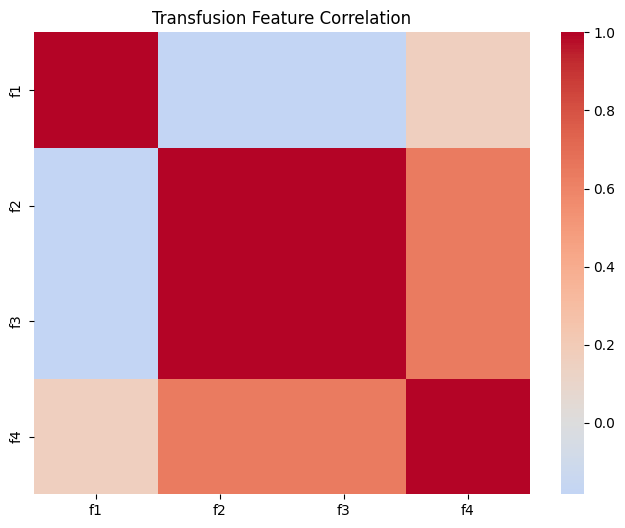

In [43]:
#EDA

transfusion_df_clean = pd.DataFrame(
    X_transfusion_raw,
    columns=[f"f{i}" for i in range(1, X_transfusion_raw.shape[1] + 1)]
)
transfusion_df_clean["class"] = y_transfusion_processed

print("Transfusion EDA Summary")
print("-" * 40)

print("Number of samples:", transfusion_df_clean.shape[0])
print("Number of features:", transfusion_df_clean.shape[1] - 1)
print("Number of classes:", transfusion_df_clean["class"].nunique())

print("\nMissing values:", transfusion_df_clean.isna().sum().sum())

print("\nClass distribution:")
print(transfusion_df_clean["class"].value_counts().sort_index())

print("\nFeature summary:")
display(transfusion_df_clean.drop(columns=["class"]).describe())

plt.figure(figsize=(8, 6))
sns.heatmap(transfusion_df_clean.drop(columns=["class"]).corr(), cmap="coolwarm", center=0)
plt.title("Transfusion Feature Correlation")
plt.show()

Although **perfect correlation** exists between **Frequency** and **Monetary** features, both were retained to remain consistent with the original work.

In [44]:
# Deterministic SVM (formulation check)

def inhomogeneous_cubic_kernel(X1, X2, c):
    return (c + X1 @ X2.T) ** 3

def get_c_parameter_transfusion(X):
    c_val = np.max(np.std(X, axis=0, ddof=1))
    if np.isnan(c_val) or c_val <= 0:
        c_val = 1.0
    return c_val

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_transfusion_raw,
    y_transfusion_processed,
    test_size=0.25,
    stratify=y_transfusion_processed,
    random_state=42
)

X_train, X_test = preprocess_transfusion_split(X_train_raw, X_test_raw)

c_kernel = get_c_parameter_transfusion(X_train)

K = inhomogeneous_cubic_kernel(X_train, X_train, c_kernel)
K = stabilize_kernel(K)

classes = np.unique(y_train)
transfusion_det_models = []

nu_test = 1.0

for cls in classes:

    y_binary = np.where(y_train == cls, 1, -1)
    n = len(y_binary)

    u = cp.Variable(n)
    gamma_var = cp.Variable()
    xi = cp.Variable(n)

    decision = K @ cp.multiply(y_binary, u)

    constraints = [
        cp.multiply(y_binary, decision - gamma_var) >= 1 - xi,
        xi >= 0
    ]

    objective = cp.Minimize(
        cp.norm(u, 1) + nu_test * cp.sum(xi)
    )

    problem = cp.Problem(objective, constraints)
    problem.solve(solver=cp.CLARABEL, verbose=False)

    transfusion_det_models.append({
        "class": cls,
        "u": np.asarray(u.value).reshape(-1),
        "gamma": float(gamma_var.value),
        "xi": np.asarray(xi.value).reshape(-1),
        "y_binary": y_binary,
        "X_train": X_train,
        "c_kernel": c_kernel,
        "status": problem.status
    })

print("Transfusion deterministic nonlinear SVM formulation solved successfully.")

Transfusion deterministic nonlinear SVM formulation solved successfully.


In [46]:
#Deterministic SVM (pilot search + 96-run)

TRANSFUSION_DET_PILOT_SEEDS = [0, 1, 2]

def train_transfusion_deterministic_binary_eq9(X_train, y_binary, nu, c_kernel):
    n = len(y_binary)

    K = inhomogeneous_cubic_kernel(X_train, X_train, c_kernel)
    K = stabilize_kernel(K)

    u = cp.Variable(n)
    gamma_var = cp.Variable()
    xi = cp.Variable(n)

    decision = K @ cp.multiply(y_binary, u)

    constraints = [
        cp.multiply(y_binary, decision - gamma_var) >= 1 - xi,
        xi >= 0
    ]

    objective = cp.Minimize(
        cp.norm(u, 1) + nu * cp.sum(xi)
    )

    problem = cp.Problem(objective, constraints)

    try:
        problem.solve(solver=cp.CLARABEL, verbose=False)
    except Exception as e:
        return None, str(e)

    if problem.status not in ACCEPTABLE_STATUSES:
        return None, f"Status={problem.status}"

    if u.value is None or gamma_var.value is None or xi.value is None:
        return None, f"Status={problem.status}, missing variable value"

    u_val = np.asarray(u.value).reshape(-1)
    gamma_val = float(gamma_var.value)
    xi_val = np.asarray(xi.value).reshape(-1)

    b_val, train_error_count = linear_search_b_eq10(
        K=K,
        y_binary=y_binary,
        u_val=u_val,
        gamma_val=gamma_val,
        xi_val=xi_val
    )

    return {
        "u": u_val,
        "gamma": gamma_val,
        "xi": xi_val,
        "b": b_val,
        "train_error_count": train_error_count,
        "y_binary": y_binary,
        "X_train": X_train,
        "c_kernel": c_kernel,
        "nu": nu,
        "status": problem.status
    }, None

def train_transfusion_deterministic_ovr_fixed_nu(X_train, y_train, nu):
    c_kernel = get_c_parameter_transfusion(X_train)
    classes = np.unique(y_train)

    models = []
    errors = []

    for cls in classes:
        y_binary = np.where(y_train == cls, 1, -1)

        model, err = train_transfusion_deterministic_binary_eq9(
            X_train=X_train,
            y_binary=y_binary,
            nu=nu,
            c_kernel=c_kernel
        )

        if model is None:
            errors.append({
                "class": cls,
                "nu": nu,
                "error": err
            })
            return None, errors

        model["class"] = cls
        models.append(model)

    return models, errors

def predict_transfusion_deterministic_ovr(models, X_test):
    scores = []

    for model in models:
        K_test = inhomogeneous_cubic_kernel(
            X_test,
            model["X_train"],
            model["c_kernel"]
        )

        score = K_test @ (model["y_binary"] * model["u"]) - model["b"]
        scores.append(score)

    scores = np.vstack(scores).T
    class_labels = np.array([model["class"] for model in models])

    return class_labels[np.argmax(scores, axis=1)]

def run_transfusion_det_pilot_for_split(test_size):
    pilot_results = []
    pilot_failures = []

    for nu in nu_values:

        pilot_metrics = []
        failed = False

        for seed in TRANSFUSION_DET_PILOT_SEEDS:
            X_train_raw, X_test_raw, y_train, y_test = train_test_split(
                X_transfusion_raw,
                y_transfusion_processed,
                test_size=test_size,
                stratify=y_transfusion_processed,
                random_state=seed
            )

            X_train, X_test = preprocess_transfusion_split(X_train_raw, X_test_raw)

            models, errors = train_transfusion_deterministic_ovr_fixed_nu(
                X_train=X_train,
                y_train=y_train,
                nu=nu
            )

            if models is None:
                failed = True
                pilot_failures.extend(errors)
                break

            y_pred = predict_transfusion_deterministic_ovr(models, X_test)

            pilot_metrics.append({
                "accuracy": accuracy_score(y_test, y_pred),
                "f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0)
            })

        if failed or len(pilot_metrics) == 0:
            continue

        pilot_metrics_df = pd.DataFrame(pilot_metrics)

        pilot_results.append({
            "nu": nu,
            "Pilot Accuracy Mean": pilot_metrics_df["accuracy"].mean(),
            "Pilot F1 Mean": pilot_metrics_df["f1_macro"].mean()
        })

    pilot_results_df = pd.DataFrame(pilot_results)

    if len(pilot_results_df) == 0:
        raise RuntimeError("All Transfusion deterministic pilot candidates failed with CLARABEL. Stop before fallback solver.")

    pilot_results_df = pilot_results_df.sort_values(
        by=["Pilot Accuracy Mean", "Pilot F1 Mean"],
        ascending=False
    ).reset_index(drop=True)

    return pilot_results_df.loc[0, "nu"], pilot_results_df, pilot_failures


transfusion_det_split_selected_nu = {}
transfusion_det_pilot_tables = {}

for split_name, test_size in transfusion_split_settings.items():

    best_nu, pilot_table, pilot_failures = run_transfusion_det_pilot_for_split(
        test_size=test_size
    )

    transfusion_det_split_selected_nu[split_name] = best_nu
    transfusion_det_pilot_tables[split_name] = pilot_table

    print(f"\nTransfusion deterministic pilot search completed for split {split_name}.")
    print("Deviation note: Exact formulation with reduced hyperparameter search due to computational cost.")
    print("Selected nu:", best_nu)
    print("Top pilot candidates:")
    display(pilot_table.head(5))


transfusion_det_results = []
transfusion_det_failed_runs = []

for split_name, test_size in transfusion_split_settings.items():

    selected_nu = transfusion_det_split_selected_nu[split_name]

    split_metrics = []
    failed_solver_runs = 0
    optimal_runs = 0
    optimal_inaccurate_runs = 0

    for seed in tqdm(range(N_REPEATS), desc=f"Transfusion deterministic SVM fixed nu - {split_name}"):

        X_train_raw, X_test_raw, y_train, y_test = train_test_split(
            X_transfusion_raw,
            y_transfusion_processed,
            test_size=test_size,
            stratify=y_transfusion_processed,
            random_state=seed
        )

        X_train, X_test = preprocess_transfusion_split(X_train_raw, X_test_raw)

        models, errors = train_transfusion_deterministic_ovr_fixed_nu(
            X_train=X_train,
            y_train=y_train,
            nu=selected_nu
        )

        if models is None:
            failed_solver_runs += 1
            transfusion_det_failed_runs.append({
                "Split": split_name,
                "Seed": seed,
                "Errors": errors
            })
            continue

        model_statuses = [m["status"] for m in models]

        if all(status == "optimal" for status in model_statuses):
            optimal_runs += 1
        elif any(status == "optimal_inaccurate" for status in model_statuses):
            optimal_inaccurate_runs += 1

        y_pred = predict_transfusion_deterministic_ovr(models, X_test)

        split_metrics.append({
            "accuracy": accuracy_score(y_test, y_pred),
            "precision_macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
            "recall_macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
            "f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
            "statuses": model_statuses
        })

    split_metrics_df = pd.DataFrame(split_metrics)

    transfusion_det_results.append({
        "Dataset": "Transfusion",
        "Model": "Deterministic nonlinear kernel SVM",
        "Search Note": "Exact formulation with reduced hyperparameter search due to computational cost",
        "Split": split_name,
        "Preprocessing": "Standardization",
        "Kernel": "Inhomogeneous cubic",
        "Solver": "CLARABEL",
        "Nmax": NMAX,
        "Selected nu": selected_nu,
        "Valid Runs": len(split_metrics),
        "Optimal Runs": optimal_runs,
        "Optimal Inaccurate Runs": optimal_inaccurate_runs,
        "Failed Solver Runs": failed_solver_runs,
        "Accuracy Mean": split_metrics_df["accuracy"].mean() if len(split_metrics_df) > 0 else np.nan,
        "Accuracy Std": split_metrics_df["accuracy"].std() if len(split_metrics_df) > 0 else np.nan,
        "Precision Mean": split_metrics_df["precision_macro"].mean() if len(split_metrics_df) > 0 else np.nan,
        "Recall Mean": split_metrics_df["recall_macro"].mean() if len(split_metrics_df) > 0 else np.nan,
        "F1 Mean": split_metrics_df["f1_macro"].mean() if len(split_metrics_df) > 0 else np.nan
    })

transfusion_det_results_df = pd.DataFrame(transfusion_det_results)

print("Transfusion Deterministic Nonlinear Kernel SVM Results (96-run fixed selected nu):")
display(transfusion_det_results_df)

print(
    "\nNote: Some CLARABEL solutions may be returned as optimal_inaccurate; "
    "results are retained but flagged because the paper used MOSEK."
)

if len(transfusion_det_failed_runs) > 0:
    print("\nSome deterministic fixed-nu runs failed with CLARABEL:")
    display(pd.DataFrame(transfusion_det_failed_runs))

C:\Users\husse\AppData\Local\Temp\ipykernel_26660\2968190082.py:29: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  problem.solve(solver=cp.CLARABEL, verbose=False)
C:\Users\husse\AppData\Local\Temp\ipykernel_26660\2968190082.py:29: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  problem.solve(solver=cp.CLARABEL, verbose=False)
C:\Users\husse\AppData\Local\Temp\ipykernel_26660\2968190082.py:29: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  problem.solve(solver=cp.CLARABEL, verbose=False)



Transfusion deterministic pilot search completed for split 75/25.
Deviation note: Exact formulation with reduced hyperparameter search due to computational cost.
Selected nu: 1.0
Top pilot candidates:


,nu,Pilot Accuracy Mean,Pilot F1 Mean
0,1.000000,0.805704,0.686016
1,0.177828,0.802139,0.682783
2,0.031623,0.793226,0.655907
3,0.001000,0.784314,0.593023
4,0.005623,0.775401,0.640489


C:\Users\husse\AppData\Local\Temp\ipykernel_26660\2968190082.py:29: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  problem.solve(solver=cp.CLARABEL, verbose=False)



Transfusion deterministic pilot search completed for split 50/50.
Deviation note: Exact formulation with reduced hyperparameter search due to computational cost.
Selected nu: 1.0
Top pilot candidates:


...

,nu,Pilot Accuracy Mean,Pilot F1 Mean
0,0.005623,0.768271,0.465076
1,0.001000,0.765894,0.457336
2,0.031623,0.762923,0.519241
3,0.177828,0.762329,0.588151
4,1.000000,0.759952,0.570578


Transfusion deterministic SVM fixed nu - 75/25:   0%|          | 0/96 [00:00<?, ?it/s]C:\Users\husse\AppData\Local\Temp\ipykernel_26660\2968190082.py:29: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  problem.solve(solver=cp.CLARABEL, verbose=False)
Transfusion deterministic SVM fixed nu - 75/25:   1%|          | 1/96 [00:11<18:46, 11.85s/it]C:\Users\husse\AppData\Local\Temp\ipykernel_26660\2968190082.py:29: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  problem.solve(solver=cp.CLARABEL, verbose=False)
Transfusion deterministic SVM fixed nu - 75/25:   5%|▌         | 5/96 [00:59<17:54, 11.81s/it]C:\Users\husse\AppData\Local\Temp\ipykernel_26660\2968190082.py:29: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more informatio

Transfusion Deterministic Nonlinear Kernel SVM Results (96-run fixed selected nu):


,Dataset,Model,Search Note,Split,Preprocessing,Kernel,Solver,Nmax,Selected nu,Valid Runs,Optimal Runs,Optimal Inaccurate Runs,Failed Solver Runs,Accuracy Mean,Accuracy Std,Precision Mean,Recall Mean,F1 Mean
0,Transfusion,Deterministic nonlinear kernel SVM,Exact formulation with reduced hyperparameter ...,75/25,Standardization,Inhomogeneous cubic,CLARABEL,10000,1.000000,96,59,37,0,0.795566,0.017972,0.726132,0.646110,0.663601
1,Transfusion,Deterministic nonlinear kernel SVM,Exact formulation with reduced hyperparameter ...,50/50,Standardization,Inhomogeneous cubic,CLARABEL,10000,1.000000,96,68,28,0,0.786709,0.013050,0.713490,0.626988,0.638375
2,Transfusion,Deterministic nonlinear kernel SVM,Exact formulation with reduced hyperparameter ...,25/75,Standardization,Inhomogeneous cubic,CLARABEL,10000,0.005623,96,96,0,0,0.764966,0.009674,0.697985,0.524933,0.485460



Note: Some CLARABEL solutions may be returned as optimal_inaccurate; results are retained but flagged because the paper used MOSEK.


In [47]:
# Robust SVM (formulation check)

import scipy.special

def compute_delta_polynomial_inhomogeneous(X, eta, n_features, p_norm, degree, c):
    C_np = compute_C_np(n_features, p_norm)
    x_norm = np.linalg.norm(X, axis=1)

    delta_homogeneous = np.zeros_like(eta, dtype=float)

    for k in range(1, degree + 1):
        delta_homogeneous += (
            scipy.special.comb(degree, k)
            * (x_norm ** (degree - k))
            * ((C_np * eta) ** k)
        )

    if c == 0:
        delta = delta_homogeneous
    else:
        extra_sum = np.zeros_like(eta, dtype=float)

        for k in range(1, degree):
            inner_sum = np.zeros_like(eta, dtype=float)

            for j in range(1, degree - k + 1):
                inner_sum += (
                    scipy.special.comb(degree - k, j)
                    * (x_norm ** (degree - k - j))
                    * ((C_np * eta) ** j)
                )

            extra_sum += (
                scipy.special.comb(degree, k)
                * (c ** k)
                * inner_sum
            ) ** 2

        delta = np.sqrt(delta_homogeneous**2 + extra_sum)

    delta = np.nan_to_num(delta, nan=0.0, posinf=0.0, neginf=0.0)
    return delta

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_transfusion_raw,
    y_transfusion_processed,
    test_size=0.25,
    stratify=y_transfusion_processed,
    random_state=42
)

X_train, X_test = preprocess_transfusion_split(X_train_raw, X_test_raw)

n_samples, n_features = X_train.shape

c_kernel = get_c_parameter_transfusion(X_train)

K = inhomogeneous_cubic_kernel(X_train, X_train, c_kernel)
K = stabilize_kernel(K)

K_diag_sqrt = np.sqrt(np.maximum(np.diag(K), 0))

rho = 1e-3
p_norm = 1
nu = 1.0
degree = 3

classes = np.unique(y_train)
transfusion_robust_models = []

for cls in classes:

    y_binary = np.where(y_train == cls, 1, -1)

    class_pos = X_train[y_binary == 1]
    class_neg = X_train[y_binary == -1]

    eta_pos = rho * np.max(np.std(class_pos, axis=0, ddof=1))
    eta_neg = rho * np.max(np.std(class_neg, axis=0, ddof=1))

    if np.isnan(eta_pos):
        eta_pos = 0.0
    if np.isnan(eta_neg):
        eta_neg = 0.0

    eta = np.where(y_binary == 1, eta_pos, eta_neg)

    delta = compute_delta_polynomial_inhomogeneous(
        X=X_train,
        eta=eta,
        n_features=n_features,
        p_norm=p_norm,
        degree=degree,
        c=c_kernel
    )

    u = cp.Variable(n_samples)
    gamma_var = cp.Variable()
    xi = cp.Variable(n_samples)
    s = cp.Variable(n_samples)

    constraints = [
        s >= u,
        s >= -u,
        xi >= 0
    ]

    uncertainty_norm = cp.sum(cp.multiply(K_diag_sqrt, s))

    for i in range(n_samples):
        margin_term = y_binary[i] * cp.sum(
            cp.multiply(K[i, :], cp.multiply(y_binary, u))
        )

        constraints.append(
            margin_term - delta[i] * uncertainty_norm >= 1 - xi[i] + y_binary[i] * gamma_var
        )

    objective = cp.Minimize(
        cp.norm(u, 1) + nu * cp.sum(xi)
    )

    problem = cp.Problem(objective, constraints)
    problem.solve(solver=cp.CLARABEL, verbose=False)

    if problem.status not in ACCEPTABLE_STATUSES:
        print(f"Class {cls}: CLARABEL status not accepted:", problem.status)
        continue

    if u.value is None or gamma_var.value is None or xi.value is None:
        print(f"Class {cls}: CLARABEL returned missing variable values. Status:", problem.status)
        continue

    transfusion_robust_models.append({
        "class": cls,
        "u": np.asarray(u.value).reshape(-1),
        "gamma": float(gamma_var.value),
        "xi": np.asarray(xi.value).reshape(-1),
        "y_binary": y_binary,
        "X_train": X_train,
        "c_kernel": c_kernel,
        "delta": delta,
        "rho": rho,
        "p_norm": p_norm,
        "nu": nu,
        "status": problem.status
    })

print("Transfusion robust nonlinear SVM formulation check completed.")

Transfusion robust nonlinear SVM formulation check completed.


In [51]:
# Robust SVM (restricted pilot + 96-run)

import time

TRANSFUSION_ROBUST_CANDIDATES = [
    (1.0, 1e-7, 1),
    (1.0, 1e-3, 1),
    (1.0, 1e-2, 1),
    (0.1778279410038923, 1e-3, 1),
    (0.1778279410038923, 1e-2, 2),
    (0.005623413251903491, 1e-2, np.inf)
]

TRANSFUSION_ROBUST_PILOT_SEED = 0

transfusion_robust_deviation_note = (
    "Exact formulation with restricted pilot hyperparameter search due to high computational cost "
    "of the inhomogeneous cubic robust formulation under CLARABEL."
)

def run_transfusion_restricted_robust_pilot_for_split(test_size, split_name):
    pilot_results = []
    pilot_failures = []

    pilot_start = time.time()

    for nu, rho, p_norm in TRANSFUSION_ROBUST_CANDIDATES:

        candidate_start = time.time()

        X_train_raw, X_test_raw, y_train, y_test = train_test_split(
            X_transfusion_raw,
            y_transfusion_processed,
            test_size=test_size,
            stratify=y_transfusion_processed,
            random_state=TRANSFUSION_ROBUST_PILOT_SEED
        )

        X_train, X_test = preprocess_transfusion_split(X_train_raw, X_test_raw)

        models, errors = train_transfusion_robust_ovr_fixed_params(
            X_train=X_train,
            y_train=y_train,
            nu=nu,
            rho=rho,
            p_norm=p_norm
        )

        candidate_elapsed = time.time() - candidate_start

        if models is None:
            pilot_failures.append({
                "Split": split_name,
                "nu": nu,
                "rho": rho,
                "p": "inf" if p_norm == np.inf else p_norm,
                "Errors": errors,
                "Runtime Seconds": candidate_elapsed
            })
            continue

        y_pred = predict_transfusion_robust_ovr(models, X_test)

        pilot_results.append({
            "nu": nu,
            "rho": rho,
            "p_norm": p_norm,
            "p_label": "inf" if p_norm == np.inf else p_norm,
            "Pilot Accuracy": accuracy_score(y_test, y_pred),
            "Pilot F1": f1_score(y_test, y_pred, average="macro", zero_division=0),
            "Statuses": [m["status"] for m in models],
            "Runtime Seconds": candidate_elapsed
        })

        print(
            f"Candidate done | split={split_name}, nu={nu}, rho={rho}, "
            f"p={'inf' if p_norm == np.inf else p_norm}, time={candidate_elapsed:.2f}s"
        )

    pilot_elapsed = time.time() - pilot_start

    pilot_results_df = pd.DataFrame(pilot_results)

    if len(pilot_results_df) == 0:
        raise RuntimeError(
            f"All restricted Transfusion robust candidates failed for split {split_name}. "
            "Stop before fallback solver."
        )

    pilot_results_df = pilot_results_df.sort_values(
        by=["Pilot Accuracy", "Pilot F1"],
        ascending=False
    ).reset_index(drop=True)

    best_nu = pilot_results_df.loc[0, "nu"]
    best_rho = pilot_results_df.loc[0, "rho"]
    best_p = pilot_results_df.loc[0, "p_norm"]

    print(f"Pilot runtime: {pilot_elapsed:.2f} seconds")

    return best_nu, best_rho, best_p, pilot_results_df, pilot_failures, pilot_elapsed


transfusion_robust_split_selected_params = {}
transfusion_robust_pilot_tables = {}
transfusion_robust_pilot_failures = []
transfusion_robust_pilot_runtimes = {}

for split_name, test_size in transfusion_split_settings.items():

    best_nu, best_rho, best_p, pilot_table, pilot_failures, pilot_elapsed = (
        run_transfusion_restricted_robust_pilot_for_split(
            test_size=test_size,
            split_name=split_name
        )
    )

    transfusion_robust_split_selected_params[split_name] = {
        "nu": best_nu,
        "rho": best_rho,
        "p_norm": best_p
    }

    transfusion_robust_pilot_tables[split_name] = pilot_table
    transfusion_robust_pilot_failures.extend(pilot_failures)
    transfusion_robust_pilot_runtimes[split_name] = pilot_elapsed

    print(f"\nRobust pilot completed for split {split_name}.")
    print("Deviation note:", transfusion_robust_deviation_note)
    print("Selected nu:", best_nu)
    print("Selected rho:", best_rho)
    print("Selected p:", "inf" if best_p == np.inf else best_p)
    print("Top pilot candidates:")
    display(pilot_table)


transfusion_robust_results = []
transfusion_robust_failed_runs = []

for split_name, test_size in transfusion_split_settings.items():

    selected = transfusion_robust_split_selected_params[split_name]
    best_robust_nu = selected["nu"]
    best_robust_rho = selected["rho"]
    best_robust_p = selected["p_norm"]

    print("Deviation note:", transfusion_robust_deviation_note)
    print("Selected nu:", best_robust_nu)
    print("Selected rho:", best_robust_rho)
    print("Selected p:", "inf" if best_robust_p == np.inf else best_robust_p)

    split_start = time.time()

    split_metrics = []
    failed_solver_runs = 0
    optimal_runs = 0
    optimal_inaccurate_runs = 0

    for seed in tqdm(range(N_REPEATS), desc=f"Transfusion robust SVM fixed candidate - {split_name}"):

        X_train_raw, X_test_raw, y_train, y_test = train_test_split(
            X_transfusion_raw,
            y_transfusion_processed,
            test_size=test_size,
            stratify=y_transfusion_processed,
            random_state=seed
        )

        X_train, X_test = preprocess_transfusion_split(X_train_raw, X_test_raw)

        models, errors = train_transfusion_robust_ovr_fixed_params(
            X_train=X_train,
            y_train=y_train,
            nu=best_robust_nu,
            rho=best_robust_rho,
            p_norm=best_robust_p
        )

        if models is None:
            failed_solver_runs += 1
            transfusion_robust_failed_runs.append({
                "Split": split_name,
                "Seed": seed,
                "Errors": errors
            })
            continue

        model_statuses = [m["status"] for m in models]

        if all(status == "optimal" for status in model_statuses):
            optimal_runs += 1
        elif any(status == "optimal_inaccurate" for status in model_statuses):
            optimal_inaccurate_runs += 1

        y_pred = predict_transfusion_robust_ovr(models, X_test)

        split_metrics.append({
            "accuracy": accuracy_score(y_test, y_pred),
            "precision_macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
            "recall_macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
            "f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
            "statuses": model_statuses
        })

    split_elapsed = time.time() - split_start

    print(f"Split runtime: {split_elapsed:.2f} seconds")

    split_metrics_df = pd.DataFrame(split_metrics)

    transfusion_robust_results.append({
        "Dataset": "Transfusion",
        "Model": "Robust nonlinear kernel SVM",
        "Search Note": transfusion_robust_deviation_note,
        "Split": split_name,
        "Preprocessing": "Standardization",
        "Kernel": "Inhomogeneous cubic",
        "Solver": "CLARABEL",
        "Nmax": NMAX,
        "Selected nu": best_robust_nu,
        "Selected rho": best_robust_rho,
        "Selected p": "inf" if best_robust_p == np.inf else best_robust_p,
        "Valid Runs": len(split_metrics),
        "Optimal Runs": optimal_runs,
        "Optimal Inaccurate Runs": optimal_inaccurate_runs,
        "Failed Solver Runs": failed_solver_runs,
        "Pilot Runtime Seconds": transfusion_robust_pilot_runtimes[split_name],
        "Final Split Runtime Seconds": split_elapsed,
        "Accuracy Mean": split_metrics_df["accuracy"].mean() if len(split_metrics_df) > 0 else np.nan,
        "Accuracy Std": split_metrics_df["accuracy"].std() if len(split_metrics_df) > 0 else np.nan,
        "Precision Mean": split_metrics_df["precision_macro"].mean() if len(split_metrics_df) > 0 else np.nan,
        "Recall Mean": split_metrics_df["recall_macro"].mean() if len(split_metrics_df) > 0 else np.nan,
        "F1 Mean": split_metrics_df["f1_macro"].mean() if len(split_metrics_df) > 0 else np.nan
    })

transfusion_robust_results_df = pd.DataFrame(transfusion_robust_results)

print("Transfusion Robust Nonlinear Kernel SVM Results (96-run fixed restricted-pilot candidate by split):")
display(transfusion_robust_results_df)

print("\nDeviation note:", transfusion_robust_deviation_note)

print(
    "\nNote: Some CLARABEL solutions may be returned as optimal_inaccurate; "
    "results are retained but flagged."
)

if len(transfusion_robust_pilot_failures) > 0:
    print("\nSome restricted pilot candidates failed with CLARABEL:")
    display(pd.DataFrame(transfusion_robust_pilot_failures))

if len(transfusion_robust_failed_runs) > 0:
    print("\nSome robust fixed-candidate runs failed with CLARABEL:")
    display(pd.DataFrame(transfusion_robust_failed_runs))

Candidate done | split=75/25, nu=1.0, rho=1e-07, p=1, time=34.23s
Candidate done | split=75/25, nu=1.0, rho=0.001, p=1, time=37.10s
Candidate done | split=75/25, nu=1.0, rho=0.01, p=1, time=45.55s
Candidate done | split=75/25, nu=0.1778279410038923, rho=0.001, p=1, time=33.99s
Candidate done | split=75/25, nu=0.1778279410038923, rho=0.01, p=2, time=37.53s
Candidate done | split=75/25, nu=0.005623413251903491, rho=0.01, p=inf, time=28.96s
Pilot runtime: 217.38 seconds

Robust pilot completed for split 75/25.
Deviation note: Exact formulation with restricted pilot hyperparameter search due to high computational cost of the inhomogeneous cubic robust formulation under CLARABEL.
Selected nu: 1.0
Selected rho: 1e-07
Selected p: 1.0
Top pilot candidates:


,nu,rho,p_norm,p_label,Pilot Accuracy,Pilot F1,Statuses,Runtime Seconds
0,1.000000,1.000000e-07,1.0,1,0.786096,0.648496,"[optimal, optimal]",34.229297
1,1.000000,1.000000e-03,1.0,1,0.786096,0.648496,"[optimal, optimal]",37.099577
2,0.177828,1.000000e-03,1.0,1,0.780749,0.643611,"[optimal, optimal]",33.990323
3,0.005623,1.000000e-02,inf,inf,0.780749,0.549345,"[optimal, optimal]",28.958877
4,1.000000,1.000000e-02,1.0,1,0.759358,0.617030,"[optimal, optimal]",45.547820
5,0.177828,1.000000e-02,2.0,2,0.759358,0.617030,"[optimal, optimal]",37.533780


C:\Users\husse\AppData\Local\Temp\ipykernel_26660\1982876026.py:92: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  problem.solve(solver=cp.CLARABEL, verbose=False)


Candidate done | split=50/50, nu=1.0, rho=1e-07, p=1, time=7.16s
Candidate done | split=50/50, nu=1.0, rho=0.001, p=1, time=7.15s
Candidate done | split=50/50, nu=1.0, rho=0.01, p=1, time=9.68s
Candidate done | split=50/50, nu=0.1778279410038923, rho=0.001, p=1, time=6.47s
Candidate done | split=50/50, nu=0.1778279410038923, rho=0.01, p=2, time=8.32s
Candidate done | split=50/50, nu=0.005623413251903491, rho=0.01, p=inf, time=5.63s
Pilot runtime: 44.44 seconds

Robust pilot completed for split 50/50.
Deviation note: Exact formulation with restricted pilot hyperparameter search due to high computational cost of the inhomogeneous cubic robust formulation under CLARABEL.
Selected nu: 1.0
Selected rho: 0.001
Selected p: 1.0
Top pilot candidates:


,nu,rho,p_norm,p_label,Pilot Accuracy,Pilot F1,Statuses,Runtime Seconds
0,1.000000,1.000000e-03,1.0,1,0.796791,0.669688,"[optimal, optimal]",7.147741
1,1.000000,1.000000e-07,1.0,1,0.791444,0.657284,"[optimal_inaccurate, optimal_inaccurate]",7.162734
2,0.177828,1.000000e-03,1.0,1,0.788770,0.662080,"[optimal, optimal]",6.465539
3,1.000000,1.000000e-02,1.0,1,0.778075,0.516864,"[optimal, optimal]",9.676992
4,0.177828,1.000000e-02,2.0,2,0.772727,0.496571,"[optimal, optimal]",8.319460
5,0.005623,1.000000e-02,inf,inf,0.770053,0.486132,"[optimal, optimal]",5.627918


...

Split runtime: 682.15 seconds
Deviation note: Exact formulation with restricted pilot hyperparameter search due to high computational cost of the inhomogeneous cubic robust formulation under CLARABEL.
Selected nu: 1.0
Selected rho: 0.01
Selected p: 1.0


Transfusion robust SVM fixed candidate - 25/75:   8%|▊         | 8/96 [00:10<01:58,  1.34s/it]C:\Users\husse\AppData\Local\Temp\ipykernel_26660\1982876026.py:92: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  problem.solve(solver=cp.CLARABEL, verbose=False)
Transfusion robust SVM fixed candidate - 25/75:  17%|█▋        | 16/96 [00:21<01:49,  1.37s/it]C:\Users\husse\AppData\Local\Temp\ipykernel_26660\1982876026.py:92: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  problem.solve(solver=cp.CLARABEL, verbose=False)
Transfusion robust SVM fixed candidate - 25/75:  23%|██▎       | 22/96 [00:29<01:41,  1.37s/it]C:\Users\husse\AppData\Local\Temp\ipykernel_26660\1982876026.py:92: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more 

Split runtime: 132.45 seconds
Transfusion Robust Nonlinear Kernel SVM Results (96-run fixed restricted-pilot candidate by split):


,Dataset,Model,Search Note,Split,Preprocessing,Kernel,Solver,Nmax,Selected nu,Selected rho,...,Optimal Runs,Optimal Inaccurate Runs,Failed Solver Runs,Pilot Runtime Seconds,Final Split Runtime Seconds,Accuracy Mean,Accuracy Std,Precision Mean,Recall Mean,F1 Mean
0,Transfusion,Robust nonlinear kernel SVM,Exact formulation with restricted pilot hyperp...,75/25,Standardization,Inhomogeneous cubic,CLARABEL,10000,1.0,1.000000e-07,...,53,43,0,217.380765,3159.586225,0.795399,0.017968,0.725825,0.645917,0.663373
1,Transfusion,Robust nonlinear kernel SVM,Exact formulation with restricted pilot hyperp...,50/50,Standardization,Inhomogeneous cubic,CLARABEL,10000,1.0,1.000000e-03,...,96,0,0,44.435873,682.154054,0.785484,0.012204,0.713045,0.620429,0.628654
2,Transfusion,Robust nonlinear kernel SVM,Exact formulation with restricted pilot hyperp...,25/75,Standardization,Inhomogeneous cubic,CLARABEL,10000,1.0,1.000000e-02,...,89,7,0,6.945092,132.447191,0.767417,0.007045,0.684887,0.532555,0.494699



Deviation note: Exact formulation with restricted pilot hyperparameter search due to high computational cost of the inhomogeneous cubic robust formulation under CLARABEL.

Note: Some CLARABEL solutions may be returned as optimal_inaccurate; results are retained but flagged.


# Dataset-Climate (Binary Classification, Moderate Complexity)

In [53]:
# Importing dataset

climate_url = "https://raw.githubusercontent.com/husseinareefurrahman-collab/ISE521-Term-Paper/refs/heads/main/climate.dat"

climate_df = pd.read_csv(climate_url, sep=r"\s+")

target_col = climate_df.columns[-1]

X_climate = climate_df.drop(columns=[target_col]).values
y_climate = climate_df[target_col].values

print("Climate dataset loaded successfully.")
print("Shape:", X_climate.shape)

Climate dataset loaded successfully.
Shape: (540, 20)


In [54]:
#Preprocessing

X_climate_raw = X_climate.copy()
y_climate_processed = y_climate.copy()

def preprocess_climate_split(X_train, X_test):
    return X_train.copy(), X_test.copy()

print("Climate preprocessing defined successfully.")
print("\nMissing values in features:", np.isnan(X_climate_raw).sum())
print("Missing values in target:", np.isnan(y_climate_processed).sum())

Climate preprocessing defined successfully.

Missing values in features: 0
Missing values in target: 0


Climate EDA Summary
----------------------------------------
Number of samples: 540
Number of features: 20
Number of classes: 2

Class distribution:
class
0     46
1    494
Name: count, dtype: int64

Feature summary:


,f1,f2,f3,f4,f5,f6,f7,f8,f9,f10,f11,f12,f13,f14,f15,f16,f17,f18,f19,f20
count,540.000000,540.000000,540.000000,540.000000,540.000000,540.000000,540.000000,540.000000,540.000000,540.000000,540.000000,540.000000,540.000000,540.000000,540.000000,540.000000,540.000000,540.000000,540.000000,540.000000
mean,2.000000,90.500000,0.500026,0.500097,0.500027,0.500119,0.500001,0.499913,0.500059,0.500076,0.500044,0.500111,0.499984,0.500032,0.499933,0.499944,0.499946,0.500044,0.500020,0.500021
std,0.817254,52.008901,0.288939,0.288922,0.289067,0.288993,0.288827,0.288852,0.289010,0.288909,0.288860,0.288966,0.289127,0.289014,0.288822,0.288949,0.288923,0.288813,0.288936,0.289013
min,1.000000,1.000000,0.000414,0.001922,0.001181,0.001972,0.000858,0.000476,0.004590,0.000296,0.003231,0.002015,0.000419,0.001188,0.001312,0.002509,0.000732,0.000891,0.000219,0.000263
25%,1.000000,45.750000,0.249650,0.251597,0.251540,0.250158,0.250630,0.251325,0.253048,0.250402,0.252661,0.250758,0.251676,0.249669,0.249988,0.249586,0.249974,0.250412,0.252739,0.249723
50%,2.000000,90.500000,0.499998,0.499595,0.500104,0.500456,0.500903,0.499174,0.499070,0.500074,0.500295,0.500393,0.500322,0.500151,0.500625,0.499080,0.499959,0.500384,0.498955,0.499431
75%,3.000000,135.250000,0.750042,0.750011,0.749180,0.750348,0.748988,0.748166,0.750109,0.749091,0.748605,0.749447,0.749346,0.749164,0.749569,0.750012,0.747978,0.749256,0.748539,0.749792
max,3.000000,180.000000,0.999194,0.998815,0.998263,0.997673,0.998944,0.997142,0.998930,0.998506,0.997172,0.999536,0.999942,0.997718,0.997518,0.999795,0.999155,0.997265,0.999306,0.999655


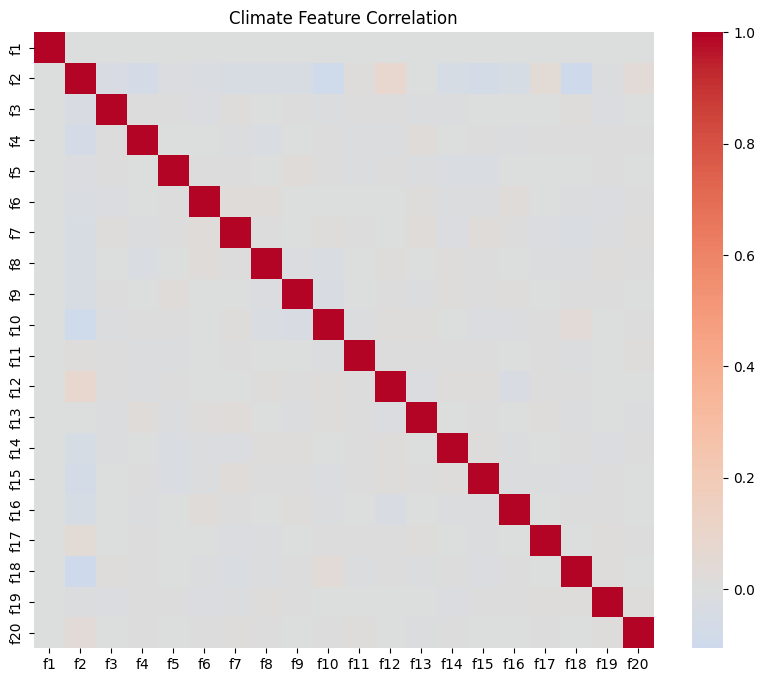

In [55]:
#EDA

climate_df_clean = pd.DataFrame(
    X_climate_raw,
    columns=[f"f{i}" for i in range(1, X_climate_raw.shape[1] + 1)]
)
climate_df_clean["class"] = y_climate_processed

print("Climate EDA Summary")
print("-" * 40)

print("Number of samples:", climate_df_clean.shape[0])
print("Number of features:", climate_df_clean.shape[1] - 1)
print("Number of classes:", climate_df_clean["class"].nunique())

print("\nClass distribution:")
print(climate_df_clean["class"].value_counts().sort_index())

print("\nFeature summary:")
display(climate_df_clean.drop(columns=["class"]).describe())

plt.figure(figsize=(10, 8))
sns.heatmap(climate_df_clean.drop(columns=["class"]).corr(), cmap="coolwarm", center=0)
plt.title("Climate Feature Correlation")
plt.show()

In [56]:
#Deterministic SVM (formulation check)

def homogeneous_linear_kernel(X1, X2):
    return X1 @ X2.T

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_climate_raw,
    y_climate_processed,
    test_size=0.25,
    stratify=y_climate_processed,
    random_state=42
)

X_train, X_test = preprocess_climate_split(X_train_raw, X_test_raw)

K = homogeneous_linear_kernel(X_train, X_train)
K = stabilize_kernel(K)

classes = np.unique(y_train)
climate_det_models = []

nu_test = 1.0

for cls in classes:

    y_binary = np.where(y_train == cls, 1, -1)
    n = len(y_binary)

    u = cp.Variable(n)
    gamma_var = cp.Variable()
    xi = cp.Variable(n)

    decision = K @ cp.multiply(y_binary, u)

    constraints = [
        cp.multiply(y_binary, decision - gamma_var) >= 1 - xi,
        xi >= 0
    ]

    objective = cp.Minimize(
        cp.norm(u, 1) + nu_test * cp.sum(xi)
    )

    problem = cp.Problem(objective, constraints)
    problem.solve(solver=cp.CLARABEL, verbose=False)

    climate_det_models.append({
        "class": cls,
        "u": np.asarray(u.value).reshape(-1),
        "gamma": float(gamma_var.value),
        "xi": np.asarray(xi.value).reshape(-1),
        "y_binary": y_binary,
        "X_train": X_train,
        "status": problem.status
    })

print("Climate deterministic nonlinear SVM formulation solved successfully.")

Climate deterministic nonlinear SVM formulation solved successfully.


In [60]:
# Deterministic SVM (restricted pilot search + 96-run)

import time

def train_climate_deterministic_binary_eq9(X_train, y_binary, nu):
    n = len(y_binary)

    K = homogeneous_linear_kernel(X_train, X_train)
    K = stabilize_kernel(K)

    u = cp.Variable(n)
    gamma_var = cp.Variable()
    xi = cp.Variable(n)

    decision = K @ cp.multiply(y_binary, u)

    constraints = [
        cp.multiply(y_binary, decision - gamma_var) >= 1 - xi,
        xi >= 0
    ]

    objective = cp.Minimize(
        cp.norm(u, 1) + nu * cp.sum(xi)
    )

    problem = cp.Problem(objective, constraints)

    try:
        problem.solve(solver=cp.CLARABEL, verbose=False)
    except Exception as e:
        return None, str(e)

    if problem.status not in ACCEPTABLE_STATUSES:
        return None, f"Status={problem.status}"

    if u.value is None or gamma_var.value is None or xi.value is None:
        return None, f"Status={problem.status}, missing variable value"

    u_val = np.asarray(u.value).reshape(-1)
    gamma_val = float(gamma_var.value)
    xi_val = np.asarray(xi.value).reshape(-1)

    b_val, train_error_count = linear_search_b_eq10(
        K=K,
        y_binary=y_binary,
        u_val=u_val,
        gamma_val=gamma_val,
        xi_val=xi_val
    )

    return {
        "u": u_val,
        "gamma": gamma_val,
        "xi": xi_val,
        "b": b_val,
        "train_error_count": train_error_count,
        "y_binary": y_binary,
        "X_train": X_train,
        "nu": nu,
        "status": problem.status
    }, None


def train_climate_deterministic_ovr_for_nu(X_train, y_train, nu):
    classes = np.unique(y_train)

    models = []
    errors = []

    for cls in classes:
        y_binary = np.where(y_train == cls, 1, -1)

        model, err = train_climate_deterministic_binary_eq9(
            X_train=X_train,
            y_binary=y_binary,
            nu=nu
        )

        if model is None:
            errors.append({
                "class": cls,
                "nu": nu,
                "error": err
            })
            return None, errors

        model["class"] = cls
        models.append(model)

    return models, errors


def predict_climate_deterministic_ovr(models, X_test):
    scores = []

    for model in models:
        K_test = homogeneous_linear_kernel(X_test, model["X_train"])
        score = K_test @ (model["y_binary"] * model["u"]) - model["b"]
        scores.append(score)

    scores = np.vstack(scores).T
    class_labels = np.array([model["class"] for model in models])

    return class_labels[np.argmax(scores, axis=1)]

climate_split_settings = {
    "75/25": 0.25,
    "50/50": 0.50,
    "25/75": 0.75
}

CLIMATE_DET_PILOT_SEED = 0
CLIMATE_DET_CANDIDATES = list(nu_values)

climate_det_deviation_note = (
    "Exact formulation with restricted pilot hyperparameter search due to computational cost."
)

def run_climate_det_pilot_for_split(test_size, split_name):
    pilot_results = []
    pilot_failures = []

    pilot_start = time.time()

    for nu in CLIMATE_DET_CANDIDATES:

        candidate_start = time.time()

        X_train_raw, X_test_raw, y_train, y_test = train_test_split(
            X_climate_raw,
            y_climate_processed,
            test_size=test_size,
            stratify=y_climate_processed,
            random_state=CLIMATE_DET_PILOT_SEED
        )

        X_train, X_test = preprocess_climate_split(X_train_raw, X_test_raw)

        models, errors = train_climate_deterministic_ovr_for_nu(
            X_train=X_train,
            y_train=y_train,
            nu=nu
        )

        candidate_elapsed = time.time() - candidate_start

        if models is None:
            pilot_failures.append({
                "Split": split_name,
                "nu": nu,
                "Errors": errors,
                "Runtime Seconds": candidate_elapsed
            })
            continue

        y_pred = predict_climate_deterministic_ovr(models, X_test)

        pilot_results.append({
            "nu": nu,
            "Pilot Accuracy": accuracy_score(y_test, y_pred),
            "Pilot F1": f1_score(y_test, y_pred, average="macro", zero_division=0),
            "Statuses": [m["status"] for m in models],
            "Runtime Seconds": candidate_elapsed
        })

    pilot_elapsed = time.time() - pilot_start

    pilot_results_df = pd.DataFrame(pilot_results)

    if len(pilot_results_df) == 0:
        raise RuntimeError(
            f"All Climate deterministic pilot candidates failed for split {split_name}. "
            "Stop before fallback solver."
        )

    pilot_results_df = pilot_results_df.sort_values(
        by=["Pilot Accuracy", "Pilot F1"],
        ascending=False
    ).reset_index(drop=True)

    best_nu = pilot_results_df.loc[0, "nu"]

    print(f"Pilot runtime: {pilot_elapsed:.2f} seconds")

    return best_nu, pilot_results_df, pilot_failures, pilot_elapsed


climate_det_split_selected_nu = {}
climate_det_pilot_tables = {}
climate_det_pilot_failures = []
climate_det_pilot_runtimes = {}

for split_name, test_size in climate_split_settings.items():

    best_nu, pilot_table, pilot_failures, pilot_elapsed = run_climate_det_pilot_for_split(
        test_size=test_size,
        split_name=split_name
    )

    climate_det_split_selected_nu[split_name] = best_nu
    climate_det_pilot_tables[split_name] = pilot_table
    climate_det_pilot_failures.extend(pilot_failures)
    climate_det_pilot_runtimes[split_name] = pilot_elapsed

    print(f"\nClimate deterministic pilot completed for split {split_name}.")
    print("Deviation note:", climate_det_deviation_note)
    print("Selected nu:", best_nu)
    print("Pilot candidates:")
    display(pilot_table)


climate_det_results = []
climate_det_failed_runs = []

for split_name, test_size in climate_split_settings.items():

    selected_nu = climate_det_split_selected_nu[split_name]

    print(f"\nStarting Climate deterministic final 96-run for split {split_name}...")
    print("Deviation note:", climate_det_deviation_note)
    print("Selected nu:", selected_nu)

    split_start = time.time()

    split_metrics = []
    failed_solver_runs = 0
    optimal_runs = 0
    optimal_inaccurate_runs = 0

    for seed in tqdm(range(N_REPEATS), desc=f"Climate deterministic SVM fixed nu - {split_name}"):

        X_train_raw, X_test_raw, y_train, y_test = train_test_split(
            X_climate_raw,
            y_climate_processed,
            test_size=test_size,
            stratify=y_climate_processed,
            random_state=seed
        )

        X_train, X_test = preprocess_climate_split(X_train_raw, X_test_raw)

        models, errors = train_climate_deterministic_ovr_for_nu(
            X_train=X_train,
            y_train=y_train,
            nu=selected_nu
        )

        if models is None:
            failed_solver_runs += 1
            climate_det_failed_runs.append({
                "Split": split_name,
                "Seed": seed,
                "Errors": errors
            })
            continue

        model_statuses = [m["status"] for m in models]

        if all(status == "optimal" for status in model_statuses):
            optimal_runs += 1
        elif any(status == "optimal_inaccurate" for status in model_statuses):
            optimal_inaccurate_runs += 1

        y_pred = predict_climate_deterministic_ovr(models, X_test)

        split_metrics.append({
            "accuracy": accuracy_score(y_test, y_pred),
            "precision_macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
            "recall_macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
            "f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
            "statuses": model_statuses
        })

    split_elapsed = time.time() - split_start

    print(f"Finished Climate deterministic final 96-run for split {split_name}.")
    print(f"Split runtime: {split_elapsed:.2f} seconds")

    split_metrics_df = pd.DataFrame(split_metrics)

    climate_det_results.append({
        "Dataset": "Climate",
        "Model": "Deterministic nonlinear kernel SVM",
        "Search Note": climate_det_deviation_note,
        "Split": split_name,
        "Preprocessing": "No transformation",
        "Kernel": "Homogeneous linear",
        "Solver": "CLARABEL",
        "Nmax": NMAX,
        "Selected nu": selected_nu,
        "Valid Runs": len(split_metrics),
        "Optimal Runs": optimal_runs,
        "Optimal Inaccurate Runs": optimal_inaccurate_runs,
        "Failed Solver Runs": failed_solver_runs,
        "Pilot Runtime Seconds": climate_det_pilot_runtimes[split_name],
        "Final Split Runtime Seconds": split_elapsed,
        "Accuracy Mean": split_metrics_df["accuracy"].mean() if len(split_metrics_df) > 0 else np.nan,
        "Accuracy Std": split_metrics_df["accuracy"].std() if len(split_metrics_df) > 0 else np.nan,
        "Precision Mean": split_metrics_df["precision_macro"].mean() if len(split_metrics_df) > 0 else np.nan,
        "Recall Mean": split_metrics_df["recall_macro"].mean() if len(split_metrics_df) > 0 else np.nan,
        "F1 Mean": split_metrics_df["f1_macro"].mean() if len(split_metrics_df) > 0 else np.nan
    })

climate_det_results_df = pd.DataFrame(climate_det_results)

print("Climate Deterministic Nonlinear Kernel SVM Results (96-run fixed selected nu):")
display(climate_det_results_df)

print("\nDeviation note:", climate_det_deviation_note)

print(
    "\nNote: Some CLARABEL solutions may be returned as optimal_inaccurate; "
    "results are retained but flagged."
)

if len(climate_det_pilot_failures) > 0:
    print("\nSome pilot candidates failed with CLARABEL:")
    display(pd.DataFrame(climate_det_pilot_failures))

if len(climate_det_failed_runs) > 0:
    print("\nSome deterministic fixed-nu runs failed with CLARABEL:")
    display(pd.DataFrame(climate_det_failed_runs))

C:\Users\husse\AppData\Local\Temp\ipykernel_26660\793671842.py:29: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  problem.solve(solver=cp.CLARABEL, verbose=False)
C:\Users\husse\AppData\Local\Temp\ipykernel_26660\793671842.py:29: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  problem.solve(solver=cp.CLARABEL, verbose=False)


Pilot runtime: 11.18 seconds

Climate deterministic pilot completed for split 75/25.
Deviation note: Exact formulation with restricted pilot hyperparameter search due to computational cost.
Selected nu: 1.0
Pilot candidates:


,nu,Pilot Accuracy,Pilot F1,Statuses,Runtime Seconds
0,1.000000,0.955556,0.862805,"[optimal, optimal]",3.514055
1,0.001000,0.911111,0.476744,"[optimal, optimal]",1.743962
2,0.005623,0.911111,0.476744,"[optimal, optimal]",1.494277
3,0.031623,0.911111,0.476744,"[optimal_inaccurate, optimal_inaccurate]",1.913531
4,0.177828,0.911111,0.476744,"[optimal_inaccurate, optimal_inaccurate]",2.506912


Pilot runtime: 4.51 seconds

Climate deterministic pilot completed for split 50/50.
Deviation note: Exact formulation with restricted pilot hyperparameter search due to computational cost.
Selected nu: 1.0
Pilot candidates:


,nu,Pilot Accuracy,Pilot F1,Statuses,Runtime Seconds
0,1.000000,0.951852,0.828437,"[optimal, optimal]",1.371032
1,0.001000,0.914815,0.477756,"[optimal, optimal]",0.702781
2,0.005623,0.914815,0.477756,"[optimal, optimal]",0.656580
3,0.031623,0.914815,0.477756,"[optimal, optimal]",0.756146
4,0.177828,0.914815,0.477756,"[optimal, optimal]",1.017476


...

Climate deterministic SVM fixed nu - 25/75: 100%|██████████| 96/96 [00:27<00:00,  3.52it/s]

Finished Climate deterministic final 96-run for split 25/75.
Split runtime: 27.27 seconds
Climate Deterministic Nonlinear Kernel SVM Results (96-run fixed selected nu):


,Dataset,Model,Search Note,Split,Preprocessing,Kernel,Solver,Nmax,Selected nu,Valid Runs,Optimal Runs,Optimal Inaccurate Runs,Failed Solver Runs,Pilot Runtime Seconds,Final Split Runtime Seconds,Accuracy Mean,Accuracy Std,Precision Mean,Recall Mean,F1 Mean
0,Climate,Deterministic nonlinear kernel SVM,Exact formulation with restricted pilot hyperp...,75/25,No transformation,Homogeneous linear,CLARABEL,10000,1.0,90,89,1,6,11.181841,352.459280,0.951276,0.015545,0.863467,0.819139,0.832510
1,Climate,Deterministic nonlinear kernel SVM,Exact formulation with restricted pilot hyperp...,50/50,No transformation,Homogeneous linear,CLARABEL,10000,1.0,92,91,1,4,4.513397,131.181312,0.946337,0.011219,0.878748,0.761307,0.796939
2,Climate,Deterministic nonlinear kernel SVM,Exact formulation with restricted pilot hyperp...,25/75,No transformation,Homogeneous linear,CLARABEL,10000,1.0,95,95,0,1,0.964743,27.269217,0.926212,0.011901,0.821695,0.639462,0.667488



Deviation note: Exact formulation with restricted pilot hyperparameter search due to computational cost.

Note: Some CLARABEL solutions may be returned as optimal_inaccurate; results are retained but flagged.

Some deterministic fixed-nu runs failed with CLARABEL:


,Split,Seed,Errors
0,75/25,6,"[{'class': 0, 'nu': 1.0, 'error': 'Solver 'CLA..."
1,75/25,44,"[{'class': 0, 'nu': 1.0, 'error': 'Solver 'CLA..."
2,75/25,54,"[{'class': 0, 'nu': 1.0, 'error': 'Solver 'CLA..."
3,75/25,57,"[{'class': 0, 'nu': 1.0, 'error': 'Solver 'CLA..."
4,75/25,60,"[{'class': 0, 'nu': 1.0, 'error': 'Solver 'CLA..."
5,75/25,61,"[{'class': 0, 'nu': 1.0, 'error': 'Solver 'CLA..."
6,50/50,62,"[{'class': 0, 'nu': 1.0, 'error': 'Solver 'CLA..."
7,50/50,65,"[{'class': 0, 'nu': 1.0, 'error': 'Solver 'CLA..."
8,50/50,71,"[{'class': 0, 'nu': 1.0, 'error': 'Solver 'CLA..."
9,50/50,82,"[{'class': 0, 'nu': 1.0, 'error': 'Solver 'CLA..."


In [61]:
# Robust SVM (formulation check)

def compute_delta_homogeneous_linear(eta, n_features, p_norm):
    C_np = compute_C_np(n_features, p_norm)
    delta = C_np * eta
    delta = np.nan_to_num(delta, nan=0.0, posinf=0.0, neginf=0.0)
    return delta

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_climate_raw,
    y_climate_processed,
    test_size=0.25,
    stratify=y_climate_processed,
    random_state=42
)

X_train, X_test = preprocess_climate_split(X_train_raw, X_test_raw)

n_samples, n_features = X_train.shape

K = homogeneous_linear_kernel(X_train, X_train)
K = stabilize_kernel(K)

K_diag_sqrt = np.sqrt(np.maximum(np.diag(K), 0))

rho = 1e-3
p_norm = 1
nu = 1.0

classes = np.unique(y_train)
climate_robust_models = []

for cls in classes:

    y_binary = np.where(y_train == cls, 1, -1)

    class_pos = X_train[y_binary == 1]
    class_neg = X_train[y_binary == -1]

    eta_pos = rho * np.max(np.std(class_pos, axis=0, ddof=1))
    eta_neg = rho * np.max(np.std(class_neg, axis=0, ddof=1))

    if np.isnan(eta_pos):
        eta_pos = 0.0
    if np.isnan(eta_neg):
        eta_neg = 0.0

    eta = np.where(y_binary == 1, eta_pos, eta_neg)
    delta = compute_delta_homogeneous_linear(eta, n_features, p_norm)

    u = cp.Variable(n_samples)
    gamma_var = cp.Variable()
    xi = cp.Variable(n_samples)
    s = cp.Variable(n_samples)

    constraints = [
        s >= u,
        s >= -u,
        xi >= 0
    ]

    uncertainty_norm = cp.sum(cp.multiply(K_diag_sqrt, s))

    for i in range(n_samples):
        margin_term = y_binary[i] * cp.sum(
            cp.multiply(K[i, :], cp.multiply(y_binary, u))
        )

        constraints.append(
            margin_term - delta[i] * uncertainty_norm >= 1 - xi[i] + y_binary[i] * gamma_var
        )

    objective = cp.Minimize(
        cp.norm(u, 1) + nu * cp.sum(xi)
    )

    problem = cp.Problem(objective, constraints)
    problem.solve(solver=cp.CLARABEL, verbose=False)

    if problem.status not in ACCEPTABLE_STATUSES:
        print(f"Class {cls}: CLARABEL status not accepted:", problem.status)
        continue

    if u.value is None or gamma_var.value is None or xi.value is None:
        print(f"Class {cls}: CLARABEL returned missing variable values. Status:", problem.status)
        continue

    climate_robust_models.append({
        "class": cls,
        "u": np.asarray(u.value).reshape(-1),
        "gamma": float(gamma_var.value),
        "xi": np.asarray(xi.value).reshape(-1),
        "y_binary": y_binary,
        "X_train": X_train,
        "delta": delta,
        "rho": rho,
        "p_norm": p_norm,
        "nu": nu,
        "status": problem.status
    })

print("Climate robust nonlinear SVM formulation check completed.")

C:\Users\husse\AppData\Local\Temp\ipykernel_26660\661693812.py:78: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  problem.solve(solver=cp.CLARABEL, verbose=False)


Climate robust nonlinear SVM formulation check completed.


In [62]:
# Robust SVM (restricted pilot + 96-run)

import time

CLIMATE_ROBUST_CANDIDATES = [
    (1.0, 1e-7, 1),
    (1.0, 1e-3, 1),
    (1.0, 1e-2, 1),
    (0.1778279410038923, 1e-3, 1),
    (0.1778279410038923, 1e-2, 2),
    (0.005623413251903491, 1e-2, np.inf)
]

CLIMATE_ROBUST_PILOT_SEED = 0

climate_robust_deviation_note = (
    "Exact formulation with restricted pilot hyperparameter search due to computational cost."
)

def linear_search_b_climate_robust_eq28(K, y_binary, u_val, gamma_val, xi_val, delta):
    omega_pos = np.max(y_binary * xi_val)
    omega_neg = np.max(-y_binary * xi_val)

    lower = gamma_val + 1 - omega_neg
    upper = gamma_val - 1 + omega_pos

    if lower > upper:
        lower, upper = upper, lower

    b_grid = np.linspace(lower, upper, NMAX)

    train_scores_without_b = K @ (y_binary * u_val)
    uncertainty_score = delta * np.sum(np.sqrt(np.maximum(np.diag(K), 0)) * np.abs(u_val))

    values = (
        y_binary.reshape(1, -1) * b_grid.reshape(-1, 1)
        - y_binary.reshape(1, -1) * train_scores_without_b.reshape(1, -1)
        + uncertainty_score.reshape(1, -1)
    )

    error_counts = np.sum(values > 0, axis=1)

    best_idx = np.argmin(error_counts)
    return b_grid[best_idx], error_counts[best_idx]


def train_climate_robust_binary_eq27(X_train, y_binary, nu, rho, p_norm):
    n_samples, n_features = X_train.shape

    K = homogeneous_linear_kernel(X_train, X_train)
    K = stabilize_kernel(K)

    K_diag_sqrt = np.sqrt(np.maximum(np.diag(K), 0))

    class_pos = X_train[y_binary == 1]
    class_neg = X_train[y_binary == -1]

    eta_pos = rho * np.max(np.std(class_pos, axis=0, ddof=1))
    eta_neg = rho * np.max(np.std(class_neg, axis=0, ddof=1))

    if np.isnan(eta_pos):
        eta_pos = 0.0
    if np.isnan(eta_neg):
        eta_neg = 0.0

    eta = np.where(y_binary == 1, eta_pos, eta_neg)
    delta = compute_delta_homogeneous_linear(eta, n_features, p_norm)

    u = cp.Variable(n_samples)
    gamma_var = cp.Variable()
    xi = cp.Variable(n_samples)
    s = cp.Variable(n_samples)

    constraints = [
        s >= u,
        s >= -u,
        xi >= 0
    ]

    uncertainty_norm = cp.sum(cp.multiply(K_diag_sqrt, s))

    for i in range(n_samples):
        margin_term = y_binary[i] * cp.sum(
            cp.multiply(K[i, :], cp.multiply(y_binary, u))
        )

        constraints.append(
            margin_term - delta[i] * uncertainty_norm >= 1 - xi[i] + y_binary[i] * gamma_var
        )

    objective = cp.Minimize(
        cp.norm(u, 1) + nu * cp.sum(xi)
    )

    problem = cp.Problem(objective, constraints)

    try:
        problem.solve(solver=cp.CLARABEL, verbose=False)
    except Exception as e:
        return None, str(e)

    if problem.status not in ACCEPTABLE_STATUSES:
        return None, f"Status={problem.status}"

    if u.value is None or gamma_var.value is None or xi.value is None:
        return None, f"Status={problem.status}, missing variable value"

    u_val = np.asarray(u.value).reshape(-1)
    gamma_val = float(gamma_var.value)
    xi_val = np.asarray(xi.value).reshape(-1)

    b_val, train_error_count = linear_search_b_climate_robust_eq28(
        K=K,
        y_binary=y_binary,
        u_val=u_val,
        gamma_val=gamma_val,
        xi_val=xi_val,
        delta=delta
    )

    return {
        "u": u_val,
        "gamma": gamma_val,
        "xi": xi_val,
        "b": b_val,
        "train_error_count": train_error_count,
        "y_binary": y_binary,
        "X_train": X_train,
        "delta": delta,
        "nu": nu,
        "rho": rho,
        "p_norm": p_norm,
        "status": problem.status
    }, None


def train_climate_robust_ovr_fixed_params(X_train, y_train, nu, rho, p_norm):
    classes = np.unique(y_train)

    models = []
    errors = []

    for cls in classes:
        y_binary = np.where(y_train == cls, 1, -1)

        model, err = train_climate_robust_binary_eq27(
            X_train=X_train,
            y_binary=y_binary,
            nu=nu,
            rho=rho,
            p_norm=p_norm
        )

        if model is None:
            errors.append({
                "class": cls,
                "nu": nu,
                "rho": rho,
                "p_norm": "inf" if p_norm == np.inf else p_norm,
                "error": err
            })
            return None, errors

        model["class"] = cls
        models.append(model)

    return models, errors


def predict_climate_robust_ovr(models, X_test):
    scores = []

    for model in models:
        K_test = homogeneous_linear_kernel(X_test, model["X_train"])
        score = K_test @ (model["y_binary"] * model["u"]) - model["b"]
        scores.append(score)

    scores = np.vstack(scores).T
    class_labels = np.array([model["class"] for model in models])

    return class_labels[np.argmax(scores, axis=1)]


def run_climate_restricted_robust_pilot_for_split(test_size, split_name):
    pilot_results = []
    pilot_failures = []

    pilot_start = time.time()

    for nu, rho, p_norm in CLIMATE_ROBUST_CANDIDATES:

        candidate_start = time.time()

        X_train_raw, X_test_raw, y_train, y_test = train_test_split(
            X_climate_raw,
            y_climate_processed,
            test_size=test_size,
            stratify=y_climate_processed,
            random_state=CLIMATE_ROBUST_PILOT_SEED
        )

        X_train, X_test = preprocess_climate_split(X_train_raw, X_test_raw)

        models, errors = train_climate_robust_ovr_fixed_params(
            X_train=X_train,
            y_train=y_train,
            nu=nu,
            rho=rho,
            p_norm=p_norm
        )

        candidate_elapsed = time.time() - candidate_start

        if models is None:
            pilot_failures.append({
                "Split": split_name,
                "nu": nu,
                "rho": rho,
                "p": "inf" if p_norm == np.inf else p_norm,
                "Errors": errors,
                "Runtime Seconds": candidate_elapsed
            })
            continue

        y_pred = predict_climate_robust_ovr(models, X_test)

        pilot_results.append({
            "nu": nu,
            "rho": rho,
            "p_norm": p_norm,
            "p_label": "inf" if p_norm == np.inf else p_norm,
            "Pilot Accuracy": accuracy_score(y_test, y_pred),
            "Pilot F1": f1_score(y_test, y_pred, average="macro", zero_division=0),
            "Statuses": [m["status"] for m in models],
            "Runtime Seconds": candidate_elapsed
        })

        print(
            f"Candidate done | split={split_name}, nu={nu}, rho={rho}, "
            f"p={'inf' if p_norm == np.inf else p_norm}, time={candidate_elapsed:.2f}s"
        )

    pilot_elapsed = time.time() - pilot_start

    pilot_results_df = pd.DataFrame(pilot_results)

    if len(pilot_results_df) == 0:
        raise RuntimeError(
            f"All restricted Climate robust candidates failed for split {split_name}. "
            "Stop before fallback solver."
        )

    pilot_results_df = pilot_results_df.sort_values(
        by=["Pilot Accuracy", "Pilot F1"],
        ascending=False
    ).reset_index(drop=True)

    best_nu = pilot_results_df.loc[0, "nu"]
    best_rho = pilot_results_df.loc[0, "rho"]
    best_p = pilot_results_df.loc[0, "p_norm"]

    print(f"Pilot runtime: {pilot_elapsed:.2f} seconds")

    return best_nu, best_rho, best_p, pilot_results_df, pilot_failures, pilot_elapsed


climate_robust_split_selected_params = {}
climate_robust_pilot_tables = {}
climate_robust_pilot_failures = []
climate_robust_pilot_runtimes = {}

for split_name, test_size in climate_split_settings.items():

    best_nu, best_rho, best_p, pilot_table, pilot_failures, pilot_elapsed = (
        run_climate_restricted_robust_pilot_for_split(
            test_size=test_size,
            split_name=split_name
        )
    )

    climate_robust_split_selected_params[split_name] = {
        "nu": best_nu,
        "rho": best_rho,
        "p_norm": best_p
    }

    climate_robust_pilot_tables[split_name] = pilot_table
    climate_robust_pilot_failures.extend(pilot_failures)
    climate_robust_pilot_runtimes[split_name] = pilot_elapsed

    print(f"\nClimate restricted robust pilot completed for split {split_name}.")
    print("Deviation note:", climate_robust_deviation_note)
    print("Selected nu:", best_nu)
    print("Selected rho:", best_rho)
    print("Selected p:", "inf" if best_p == np.inf else best_p)
    print("Top pilot candidates:")
    display(pilot_table)


climate_robust_results = []
climate_robust_failed_runs = []

for split_name, test_size in climate_split_settings.items():

    selected = climate_robust_split_selected_params[split_name]
    best_robust_nu = selected["nu"]
    best_robust_rho = selected["rho"]
    best_robust_p = selected["p_norm"]

    print(f"\nStarting Climate robust final 96-run for split {split_name}...")
    print("Deviation note:", climate_robust_deviation_note)
    print("Selected nu:", best_robust_nu)
    print("Selected rho:", best_robust_rho)
    print("Selected p:", "inf" if best_robust_p == np.inf else best_robust_p)

    split_start = time.time()

    split_metrics = []
    failed_solver_runs = 0
    optimal_runs = 0
    optimal_inaccurate_runs = 0

    for seed in tqdm(range(N_REPEATS), desc=f"Climate robust SVM fixed candidate - {split_name}"):

        X_train_raw, X_test_raw, y_train, y_test = train_test_split(
            X_climate_raw,
            y_climate_processed,
            test_size=test_size,
            stratify=y_climate_processed,
            random_state=seed
        )

        X_train, X_test = preprocess_climate_split(X_train_raw, X_test_raw)

        models, errors = train_climate_robust_ovr_fixed_params(
            X_train=X_train,
            y_train=y_train,
            nu=best_robust_nu,
            rho=best_robust_rho,
            p_norm=best_robust_p
        )

        if models is None:
            failed_solver_runs += 1
            climate_robust_failed_runs.append({
                "Split": split_name,
                "Seed": seed,
                "Errors": errors
            })
            continue

        model_statuses = [m["status"] for m in models]

        if all(status == "optimal" for status in model_statuses):
            optimal_runs += 1
        elif any(status == "optimal_inaccurate" for status in model_statuses):
            optimal_inaccurate_runs += 1

        y_pred = predict_climate_robust_ovr(models, X_test)

        split_metrics.append({
            "accuracy": accuracy_score(y_test, y_pred),
            "precision_macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
            "recall_macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
            "f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
            "statuses": model_statuses
        })

    split_elapsed = time.time() - split_start

    print(f"Finished Climate robust final 96-run for split {split_name}.")
    print(f"Split runtime: {split_elapsed:.2f} seconds")

    split_metrics_df = pd.DataFrame(split_metrics)

    climate_robust_results.append({
        "Dataset": "Climate",
        "Model": "Robust nonlinear kernel SVM",
        "Search Note": climate_robust_deviation_note,
        "Split": split_name,
        "Preprocessing": "No transformation",
        "Kernel": "Homogeneous linear",
        "Solver": "CLARABEL",
        "Nmax": NMAX,
        "Selected nu": best_robust_nu,
        "Selected rho": best_robust_rho,
        "Selected p": "inf" if best_robust_p == np.inf else best_robust_p,
        "Valid Runs": len(split_metrics),
        "Optimal Runs": optimal_runs,
        "Optimal Inaccurate Runs": optimal_inaccurate_runs,
        "Failed Solver Runs": failed_solver_runs,
        "Pilot Runtime Seconds": climate_robust_pilot_runtimes[split_name],
        "Final Split Runtime Seconds": split_elapsed,
        "Accuracy Mean": split_metrics_df["accuracy"].mean() if len(split_metrics_df) > 0 else np.nan,
        "Accuracy Std": split_metrics_df["accuracy"].std() if len(split_metrics_df) > 0 else np.nan,
        "Precision Mean": split_metrics_df["precision_macro"].mean() if len(split_metrics_df) > 0 else np.nan,
        "Recall Mean": split_metrics_df["recall_macro"].mean() if len(split_metrics_df) > 0 else np.nan,
        "F1 Mean": split_metrics_df["f1_macro"].mean() if len(split_metrics_df) > 0 else np.nan
    })

climate_robust_results_df = pd.DataFrame(climate_robust_results)

print("Climate Robust Nonlinear Kernel SVM Results (96-run fixed restricted-pilot candidate by split):")
display(climate_robust_results_df)

print("\nDeviation note:", climate_robust_deviation_note)

print(
    "\nNote: Some CLARABEL solutions may be returned as optimal_inaccurate; "
    "results are retained but flagged."
)

if len(climate_robust_pilot_failures) > 0:
    print("\nSome restricted pilot candidates failed with CLARABEL:")
    display(pd.DataFrame(climate_robust_pilot_failures))

if len(climate_robust_failed_runs) > 0:
    print("\nSome robust fixed-candidate runs failed with CLARABEL:")
    display(pd.DataFrame(climate_robust_failed_runs))

Candidate done | split=75/25, nu=1.0, rho=1e-07, p=1, time=8.97s


C:\Users\husse\AppData\Local\Temp\ipykernel_26660\99334306.py:98: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  problem.solve(solver=cp.CLARABEL, verbose=False)


Candidate done | split=75/25, nu=1.0, rho=0.001, p=1, time=5.59s


C:\Users\husse\AppData\Local\Temp\ipykernel_26660\99334306.py:98: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  problem.solve(solver=cp.CLARABEL, verbose=False)


Candidate done | split=75/25, nu=1.0, rho=0.01, p=1, time=5.61s


...

Climate robust SVM fixed candidate - 25/75:  80%|████████  | 77/96 [00:54<00:14,  1.33it/s]C:\Users\husse\AppData\Local\Temp\ipykernel_26660\99334306.py:98: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  problem.solve(solver=cp.CLARABEL, verbose=False)
Climate robust SVM fixed candidate - 25/75:  92%|█████████▏| 88/96 [01:02<00:05,  1.44it/s]C:\Users\husse\AppData\Local\Temp\ipykernel_26660\99334306.py:98: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  problem.solve(solver=cp.CLARABEL, verbose=False)
Climate robust SVM fixed candidate - 25/75: 100%|██████████| 96/96 [01:07<00:00,  1.42it/s]

Finished Climate robust final 96-run for split 25/75.
Split runtime: 67.41 seconds
Climate Robust Nonlinear Kernel SVM Results (96-run fixed restricted-pilot candidate by split):


,Dataset,Model,Search Note,Split,Preprocessing,Kernel,Solver,Nmax,Selected nu,Selected rho,...,Optimal Runs,Optimal Inaccurate Runs,Failed Solver Runs,Pilot Runtime Seconds,Final Split Runtime Seconds,Accuracy Mean,Accuracy Std,Precision Mean,Recall Mean,F1 Mean
0,Climate,Robust nonlinear kernel SVM,Exact formulation with restricted pilot hyperp...,75/25,No transformation,Homogeneous linear,CLARABEL,10000,1.0,1.000000e-07,...,92,0,4,35.781709,827.037182,0.950322,0.015972,0.861642,0.816120,0.829524
1,Climate,Robust nonlinear kernel SVM,Exact formulation with restricted pilot hyperp...,50/50,No transformation,Homogeneous linear,CLARABEL,10000,1.0,1.000000e-07,...,90,0,6,13.135685,258.108256,0.945514,0.011121,0.873195,0.760148,0.794248
2,Climate,Robust nonlinear kernel SVM,Exact formulation with restricted pilot hyperp...,25/75,No transformation,Homogeneous linear,CLARABEL,10000,1.0,1.000000e-07,...,93,2,1,3.822778,67.406632,0.926290,0.012182,0.827141,0.638288,0.666478



Deviation note: Exact formulation with restricted pilot hyperparameter search due to computational cost.

Note: Some CLARABEL solutions may be returned as optimal_inaccurate; results are retained but flagged.

Some robust fixed-candidate runs failed with CLARABEL:


,Split,Seed,Errors
0,75/25,44,"[{'class': 0, 'nu': 1.0, 'rho': 1e-07, 'p_norm..."
1,75/25,49,"[{'class': 0, 'nu': 1.0, 'rho': 1e-07, 'p_norm..."
2,75/25,59,"[{'class': 0, 'nu': 1.0, 'rho': 1e-07, 'p_norm..."
3,75/25,60,"[{'class': 0, 'nu': 1.0, 'rho': 1e-07, 'p_norm..."
4,50/50,10,"[{'class': 0, 'nu': 1.0, 'rho': 1e-07, 'p_norm..."
5,50/50,65,"[{'class': 0, 'nu': 1.0, 'rho': 1e-07, 'p_norm..."
6,50/50,66,"[{'class': 0, 'nu': 1.0, 'rho': 1e-07, 'p_norm..."
7,50/50,82,"[{'class': 0, 'nu': 1.0, 'rho': 1e-07, 'p_norm..."
8,50/50,84,"[{'class': 0, 'nu': 1.0, 'rho': 1e-07, 'p_norm..."
9,50/50,92,"[{'class': 0, 'nu': 1.0, 'rho': 1e-07, 'p_norm..."


# Dataset-Arrhythmia (High-Dimensional, Noisy Medical Data)

In [8]:
#Import dataset

arrhythmia_url = "https://raw.githubusercontent.com/husseinareefurrahman-collab/ISE521-Term-Paper/refs/heads/main/arrhythmia.data"

arrhythmia_df = pd.read_csv(arrhythmia_url, header=None)

print("Arrhythmia dataset loaded successfully.")
print("Raw dataset shape:", arrhythmia_df.shape)

X_arrhythmia_raw_unprocessed = arrhythmia_df.iloc[:, :-1].copy()
y_arrhythmia_original = arrhythmia_df.iloc[:, -1].astype(int).values

print("\nFeature shape:", X_arrhythmia_raw_unprocessed.shape)
print("Original target shape:", y_arrhythmia_original.shape)

print("\nMissing values marked as '?':")
print(X_arrhythmia_raw_unprocessed.eq("?").sum().sum())

print("\nOriginal target classes:")
print(np.unique(y_arrhythmia_original))

print("\nOriginal class distribution:")
print(pd.Series(y_arrhythmia_original).value_counts().sort_index())

Arrhythmia dataset loaded successfully.
Raw dataset shape: (452, 280)

Feature shape: (452, 279)
Original target shape: (452,)

Missing values marked as '?':
408

Original target classes:
[ 1  2  3  4  5  6  7  8  9 10 14 15 16]

Original class distribution:
1     245
2      44
3      15
4      15
5      13
6      25
7       3
8       2
9       9
10     50
14      4
15      5
16     22
Name: count, dtype: int64


In [9]:
#Preprocessing

from sklearn.impute import SimpleImputer

y_arrhythmia_processed = np.where(y_arrhythmia_original == 1, 0, 1)

X_arrhythmia_raw = X_arrhythmia_raw_unprocessed.replace("?", np.nan).astype(float)

print("Binary target created.")
print("Classes: 0 = normal, 1 = abnormal")

print("\nBinary class distribution:")
print(pd.Series(y_arrhythmia_processed).value_counts().sort_index())

print("\nTotal NaN values after replacement:")
print(np.isnan(X_arrhythmia_raw).sum())


def preprocess_arrhythmia_split(X_train, X_test):
    imputer = SimpleImputer(strategy="mean")

    X_train_processed = imputer.fit_transform(X_train)
    X_test_processed = imputer.transform(X_test)

    return X_train_processed, X_test_processed

Binary target created.
Classes: 0 = normal, 1 = abnormal

Binary class distribution:
0    245
1    207
Name: count, dtype: int64

Total NaN values after replacement:
0      0
1      0
2      0
3      0
4      0
      ..
274    0
275    0
276    0
277    0
278    0
Length: 279, dtype: int64


Arrhythmia EDA Summary
--------------------------------------------------
Number of samples: 452
Number of features: 279
Number of classes: 2

Class distribution:
class
0    245
1    207
Name: count, dtype: int64

Missing values after replacement:
408


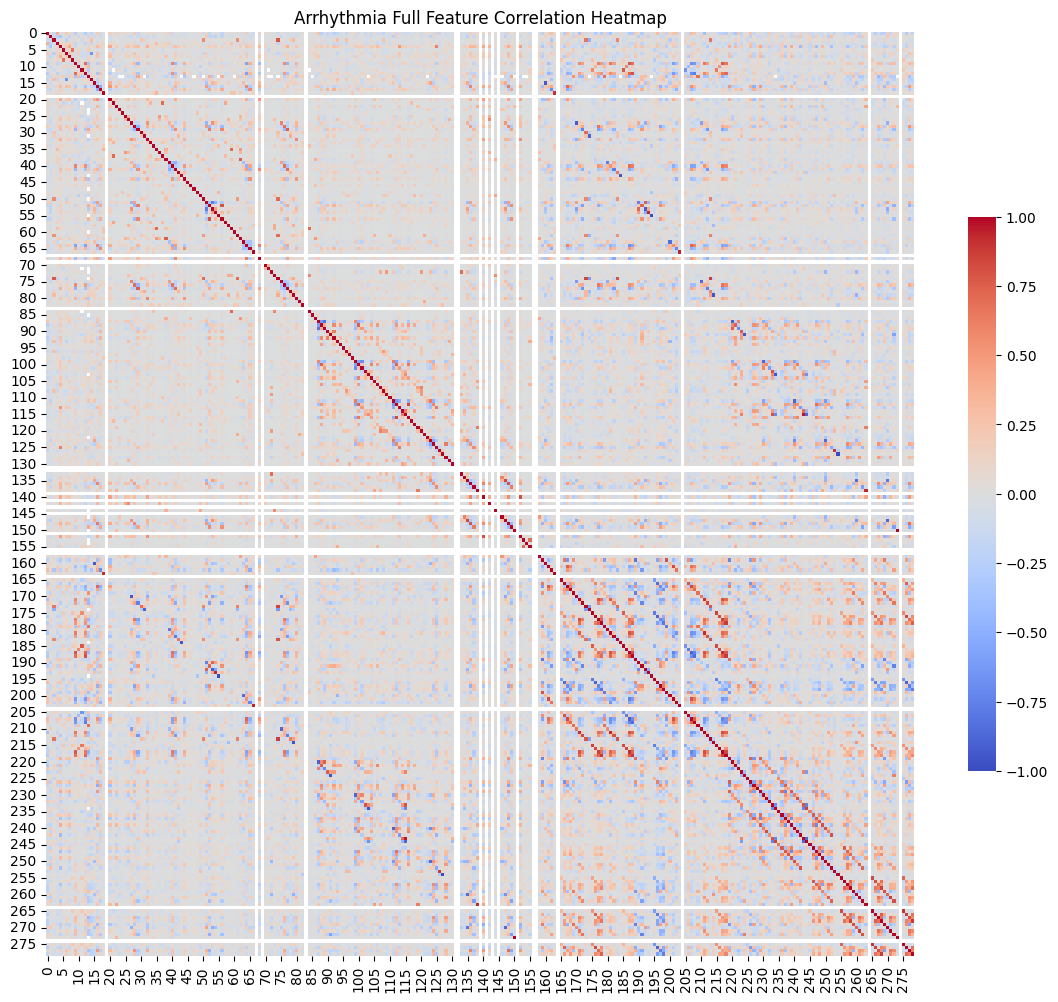

In [11]:
#EDA

arr_df = X_arrhythmia_raw.copy()
arr_df["class"] = y_arrhythmia_processed

print("Arrhythmia EDA Summary")
print("-" * 50)

print("Number of samples:", arr_df.shape[0])
print("Number of features:", arr_df.shape[1] - 1)
print("Number of classes:", arr_df["class"].nunique())

print("\nClass distribution:")
print(arr_df["class"].value_counts())

print("\nMissing values after replacement:")
print(arr_df.isnull().sum().sum())


corr_matrix = arr_df.drop(columns=["class"]).corr()

plt.figure(figsize=(14, 12))
sns.heatmap(
    corr_matrix,
    cmap="coolwarm",
    center=0,
    cbar_kws={"shrink": 0.6}
)
plt.title("Arrhythmia Full Feature Correlation Heatmap")
plt.show()

In [12]:
#Deterministic SVM formulation check

def gaussian_rbf_kernel_alpha(X1, X2, alpha):
    sq_dists = (
        np.sum(X1**2, axis=1).reshape(-1, 1)
        + np.sum(X2**2, axis=1)
        - 2 * np.dot(X1, X2.T)
    )
    return np.exp(-sq_dists / (2 * alpha**2))

X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_arrhythmia_raw,
    y_arrhythmia_processed,
    test_size=0.25,
    stratify=y_arrhythmia_processed,
    random_state=42
)

X_train, X_test = preprocess_arrhythmia_split(X_train_raw, X_test_raw)

alpha_rbf = np.max(np.std(X_train, axis=0, ddof=1))
if np.isnan(alpha_rbf) or alpha_rbf <= 0:
    alpha_rbf = 1.0

K = gaussian_rbf_kernel_alpha(X_train, X_train, alpha_rbf)
K = stabilize_kernel(K)

y_binary = np.where(y_train == 1, 1, -1)
n = len(y_binary)

u = cp.Variable(n)
gamma_var = cp.Variable()
xi = cp.Variable(n)

decision = K @ cp.multiply(y_binary, u)

constraints = [
    cp.multiply(y_binary, decision - gamma_var) >= 1 - xi,
    xi >= 0
]

objective = cp.Minimize(
    cp.norm(u, 1) + 1.0 * cp.sum(xi)
)

problem = cp.Problem(objective, constraints)
problem.solve(solver=cp.CLARABEL, verbose=False)

print("Arrhythmia deterministic formulation check completed.")

Arrhythmia deterministic formulation check completed.


In [13]:
# Step 5: Deterministic SVM (Pilot search + 96-run)

N_REPEATS = 96
NMAX = 10**4
ACCEPTABLE_STATUSES = ["optimal", "optimal_inaccurate"]

arrhythmia_split_settings = {
    "75/25": 0.25,
    "50/50": 0.50,
    "25/75": 0.75
}

ARRHYTHMIA_DET_NU_CANDIDATES = [
    1.0,
    0.1778279410038923,
    0.005623413251903491
]


def compute_alpha_rbf(X_train):
    alpha = np.max(np.std(X_train, axis=0, ddof=1))
    if np.isnan(alpha) or alpha <= 0:
        alpha = 1.0
    return alpha


def linear_search_b_eq10(K, y_binary, u_val, gamma_val, xi_val):
    omega_pos = np.max(y_binary * xi_val)
    omega_neg = np.max(-y_binary * xi_val)

    lower = gamma_val + 1 - omega_neg
    upper = gamma_val - 1 + omega_pos

    if lower > upper:
        lower, upper = upper, lower

    b_grid = np.linspace(lower, upper, NMAX)
    train_scores_without_b = K @ (y_binary * u_val)

    values = (
        y_binary.reshape(1, -1) * b_grid.reshape(-1, 1)
        - y_binary.reshape(1, -1) * train_scores_without_b.reshape(1, -1)
    )

    error_counts = np.sum(values > 0, axis=1)
    best_idx = np.argmin(error_counts)

    return b_grid[best_idx], error_counts[best_idx]


def train_arrhythmia_deterministic_binary_eq9(X_train, y_binary, nu, alpha_rbf):
    n = len(y_binary)

    K = gaussian_rbf_kernel_alpha(X_train, X_train, alpha_rbf)
    K = stabilize_kernel(K)

    u = cp.Variable(n)
    gamma_var = cp.Variable()
    xi = cp.Variable(n)

    decision = K @ cp.multiply(y_binary, u)

    constraints = [
        cp.multiply(y_binary, decision - gamma_var) >= 1 - xi,
        xi >= 0
    ]

    objective = cp.Minimize(cp.norm(u, 1) + nu * cp.sum(xi))

    problem = cp.Problem(objective, constraints)

    try:
        problem.solve(solver=cp.CLARABEL, verbose=False)
    except Exception as e:
        return None, str(e)

    if problem.status not in ACCEPTABLE_STATUSES:
        return None, f"Status={problem.status}"

    if u.value is None or gamma_var.value is None or xi.value is None:
        return None, f"Status={problem.status}, missing values"

    u_val = np.asarray(u.value).reshape(-1)
    gamma_val = float(gamma_var.value)
    xi_val = np.asarray(xi.value).reshape(-1)

    b_val, train_error_count = linear_search_b_eq10(
        K=K,
        y_binary=y_binary,
        u_val=u_val,
        gamma_val=gamma_val,
        xi_val=xi_val
    )

    return {
        "u": u_val,
        "gamma": gamma_val,
        "xi": xi_val,
        "b": b_val,
        "y_binary": y_binary,
        "X_train": X_train,
        "alpha": alpha_rbf,
        "nu": nu,
        "status": problem.status
    }, None


def predict_arrhythmia_deterministic(model, X_test):
    K_test = gaussian_rbf_kernel_alpha(X_test, model["X_train"], model["alpha"])
    score = K_test @ (model["y_binary"] * model["u"]) - model["b"]
    return np.where(score >= 0, 1, 0)


def run_arrhythmia_det_pilot_for_split(test_size, split_name):
    pilot_rows = []

    X_train_raw, X_test_raw, y_train, y_test = train_test_split(
        X_arrhythmia_raw,
        y_arrhythmia_processed,
        test_size=test_size,
        stratify=y_arrhythmia_processed,
        random_state=0
    )

    X_train, X_test = preprocess_arrhythmia_split(X_train_raw, X_test_raw)
    alpha_rbf = compute_alpha_rbf(X_train)
    y_binary = np.where(y_train == 1, 1, -1)

    for nu in ARRHYTHMIA_DET_NU_CANDIDATES:
        start = time.time()

        model, err = train_arrhythmia_deterministic_binary_eq9(
            X_train=X_train,
            y_binary=y_binary,
            nu=nu,
            alpha_rbf=alpha_rbf
        )

        runtime = time.time() - start

        if model is None:
            continue

        y_pred = predict_arrhythmia_deterministic(model, X_test)

        pilot_rows.append({
            "nu": nu,
            "Pilot Accuracy": accuracy_score(y_test, y_pred),
            "Pilot F1": f1_score(y_test, y_pred, average="macro", zero_division=0),
            "Status": model["status"],
            "Runtime Seconds": runtime
        })

    pilot_df = pd.DataFrame(pilot_rows).sort_values(
        by=["Pilot Accuracy", "Pilot F1"],
        ascending=False
    ).reset_index(drop=True)

    best_nu = pilot_df.loc[0, "nu"]

    print(f"\nArrhythmia deterministic pilot completed for split {split_name}.")
    print("Selected nu:", best_nu)
    display(pilot_df)

    return best_nu, pilot_df


arrhythmia_det_selected_nu = {}
arrhythmia_det_pilot_tables = {}

for split_name, test_size in arrhythmia_split_settings.items():
    best_nu, pilot_df = run_arrhythmia_det_pilot_for_split(test_size, split_name)
    arrhythmia_det_selected_nu[split_name] = best_nu
    arrhythmia_det_pilot_tables[split_name] = pilot_df


arrhythmia_det_results = []
arrhythmia_det_failed_runs = []

for split_name, test_size in arrhythmia_split_settings.items():

    selected_nu = arrhythmia_det_selected_nu[split_name]

    split_metrics = []
    optimal_runs = 0
    optimal_inaccurate_runs = 0
    failed_solver_runs = 0

    start_split = time.time()

    for seed in tqdm(range(N_REPEATS), desc=f"Arrhythmia deterministic SVM - {split_name}"):

        X_train_raw, X_test_raw, y_train, y_test = train_test_split(
            X_arrhythmia_raw,
            y_arrhythmia_processed,
            test_size=test_size,
            stratify=y_arrhythmia_processed,
            random_state=seed
        )

        X_train, X_test = preprocess_arrhythmia_split(X_train_raw, X_test_raw)

        alpha_rbf = compute_alpha_rbf(X_train)
        y_binary = np.where(y_train == 1, 1, -1)

        model, err = train_arrhythmia_deterministic_binary_eq9(
            X_train=X_train,
            y_binary=y_binary,
            nu=selected_nu,
            alpha_rbf=alpha_rbf
        )

        if model is None:
            failed_solver_runs += 1
            arrhythmia_det_failed_runs.append({
                "Split": split_name,
                "Seed": seed,
                "Error": err
            })
            continue

        if model["status"] == "optimal":
            optimal_runs += 1
        elif model["status"] == "optimal_inaccurate":
            optimal_inaccurate_runs += 1

        y_pred = predict_arrhythmia_deterministic(model, X_test)

        split_metrics.append({
            "accuracy": accuracy_score(y_test, y_pred),
            "precision_macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
            "recall_macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
            "f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
            "status": model["status"]
        })

    split_runtime = time.time() - start_split
    split_metrics_df = pd.DataFrame(split_metrics)

    arrhythmia_det_results.append({
        "Dataset": "Arrhythmia",
        "Model": "Deterministic nonlinear kernel SVM",
        "Search Note": "Exact formulation with restricted hyperparameter search due to high computational cost of the high-dimensional RBF kernel under CLARABEL.",
        "Split": split_name,
        "Preprocessing": "No transformation; mean imputation only",
        "Kernel": "Gaussian RBF",
        "Solver": "CLARABEL",
        "Nmax": NMAX,
        "Selected nu": selected_nu,
        "Valid Runs": len(split_metrics),
        "Optimal Runs": optimal_runs,
        "Optimal Inaccurate Runs": optimal_inaccurate_runs,
        "Failed Solver Runs": failed_solver_runs,
        "Runtime Seconds": split_runtime,
        "Accuracy Mean": split_metrics_df["accuracy"].mean(),
        "Accuracy Std": split_metrics_df["accuracy"].std(),
        "Precision Mean": split_metrics_df["precision_macro"].mean(),
        "Recall Mean": split_metrics_df["recall_macro"].mean(),
        "F1 Mean": split_metrics_df["f1_macro"].mean()
    })

arrhythmia_det_results_df = pd.DataFrame(arrhythmia_det_results)

print("Arrhythmia Deterministic Nonlinear Kernel SVM Results:")
display(arrhythmia_det_results_df)

if len(arrhythmia_det_failed_runs) > 0:
    print("\nFailed deterministic runs:")
    display(pd.DataFrame(arrhythmia_det_failed_runs))


Arrhythmia deterministic pilot completed for split 75/25.
Selected nu: 0.1778279410038923


,nu,Pilot Accuracy,Pilot F1,Status,Runtime Seconds
0,0.177828,0.539823,0.350575,optimal,0.276253
1,0.005623,0.539823,0.350575,optimal,0.322714
2,1.000000,0.495575,0.395382,optimal,0.622225



Arrhythmia deterministic pilot completed for split 50/50.
Selected nu: 0.1778279410038923


,nu,Pilot Accuracy,Pilot F1,Status,Runtime Seconds
0,0.177828,0.544248,0.352436,optimal,0.252382
1,0.005623,0.544248,0.352436,optimal,0.159955
2,1.000000,0.486726,0.384774,optimal,0.188038



Arrhythmia deterministic pilot completed for split 25/75.
Selected nu: 0.1778279410038923


,nu,Pilot Accuracy,Pilot F1,Status,Runtime Seconds
0,0.177828,0.542773,0.351816,optimal,0.034451
1,0.005623,0.542773,0.351816,optimal,0.029785
2,1.000000,0.460177,0.319807,optimal,0.044613


Arrhythmia deterministic SVM - 25/75: 100%|██████████| 96/96 [00:03<00:00, 27.44it/s]

Arrhythmia Deterministic Nonlinear Kernel SVM Results:


,Dataset,Model,Search Note,Split,Preprocessing,Kernel,Solver,Nmax,Selected nu,Valid Runs,Optimal Runs,Optimal Inaccurate Runs,Failed Solver Runs,Runtime Seconds,Accuracy Mean,Accuracy Std,Precision Mean,Recall Mean,F1 Mean
0,Arrhythmia,Deterministic nonlinear kernel SVM,Exact formulation with restricted hyperparamet...,75/25,No transformation; mean imputation only,Gaussian RBF,CLARABEL,10000,0.177828,96,96,0,0,38.821716,0.539823,1.116051e-16,0.269912,0.5,0.350575
1,Arrhythmia,Deterministic nonlinear kernel SVM,Exact formulation with restricted hyperparamet...,50/50,No transformation; mean imputation only,Gaussian RBF,CLARABEL,10000,0.177828,96,96,0,0,16.034081,0.541759,2.206560e-03,0.270879,0.5,0.351389
2,Arrhythmia,Deterministic nonlinear kernel SVM,Exact formulation with restricted hyperparamet...,25/75,No transformation; mean imputation only,Gaussian RBF,CLARABEL,10000,0.177828,96,96,0,0,3.499385,0.542773,1.116051e-16,0.271386,0.5,0.351816


In [15]:
#Robust SVM formulation check

def compute_C_np(n_features, p_norm):
    if p_norm <= 2:
        return 1.0
    elif p_norm == np.inf:
        return np.sqrt(n_features)
    else:
        return n_features ** ((p_norm - 2) / (2 * p_norm))

def gaussian_delta(alpha, eta, n_features, p_norm):
    C_np = compute_C_np(n_features, p_norm)
    delta = np.sqrt(2 - 2 * np.exp(-((C_np * eta) ** 2) / (2 * alpha**2)))
    return np.nan_to_num(delta, nan=0.0, posinf=0.0, neginf=0.0)


X_train_raw, X_test_raw, y_train, y_test = train_test_split(
    X_arrhythmia_raw,
    y_arrhythmia_processed,
    test_size=0.25,
    stratify=y_arrhythmia_processed,
    random_state=42
)

X_train, X_test = preprocess_arrhythmia_split(X_train_raw, X_test_raw)

n_samples, n_features = X_train.shape

alpha_rbf = compute_alpha_rbf(X_train)

K = gaussian_rbf_kernel_alpha(X_train, X_train, alpha_rbf)
K = stabilize_kernel(K)

K_diag_sqrt = np.sqrt(np.maximum(np.diag(K), 0))

rho = 1e-3
p_norm = 1
nu = 1.0

y_binary = np.where(y_train == 1, 1, -1)

class_pos = X_train[y_binary == 1]
class_neg = X_train[y_binary == -1]

eta_pos = rho * np.max(np.std(class_pos, axis=0, ddof=1))
eta_neg = rho * np.max(np.std(class_neg, axis=0, ddof=1))

eta_pos = 0.0 if np.isnan(eta_pos) else eta_pos
eta_neg = 0.0 if np.isnan(eta_neg) else eta_neg

eta = np.where(y_binary == 1, eta_pos, eta_neg)
delta = gaussian_delta(alpha_rbf, eta, n_features, p_norm)

u = cp.Variable(n_samples)
gamma_var = cp.Variable()
xi = cp.Variable(n_samples)
s = cp.Variable(n_samples)

constraints = [
    s >= u,
    s >= -u,
    xi >= 0
]

uncertainty_norm = cp.sum(cp.multiply(K_diag_sqrt, s))

for i in range(n_samples):
    margin_term = y_binary[i] * cp.sum(
        cp.multiply(K[i, :], cp.multiply(y_binary, u))
    )

    constraints.append(
        margin_term - delta[i] * uncertainty_norm >= 1 - xi[i] + y_binary[i] * gamma_var
    )

objective = cp.Minimize(cp.norm(u, 1) + nu * cp.sum(xi))

problem = cp.Problem(objective, constraints)
problem.solve(solver=cp.CLARABEL, verbose=False)

print("Arrhythmia robust formulation check completed.")
print("Solver status:", problem.status)

Arrhythmia robust formulation check completed.
Solver status: optimal


In [16]:
#Robust SVM (Pilot + 96-run)

ARRHYTHMIA_ROBUST_CANDIDATES = [
    (1.0, 1e-7, 1),
    (1.0, 1e-3, 1),
    (1.0, 1e-2, 1),
    (0.1778279410038923, 1e-3, 1),
    (0.1778279410038923, 1e-2, 2),
    (0.005623413251903491, 1e-2, np.inf)
]


def linear_search_b_robust_eq28(K, y_binary, u_val, gamma_val, xi_val, delta):
    omega_pos = np.max(y_binary * xi_val)
    omega_neg = np.max(-y_binary * xi_val)

    lower = gamma_val + 1 - omega_neg
    upper = gamma_val - 1 + omega_pos

    if lower > upper:
        lower, upper = upper, lower

    b_grid = np.linspace(lower, upper, NMAX)

    train_scores_without_b = K @ (y_binary * u_val)
    uncertainty_score = delta * np.sum(np.sqrt(np.maximum(np.diag(K), 0)) * np.abs(u_val))

    values = (
        y_binary.reshape(1, -1) * b_grid.reshape(-1, 1)
        - y_binary.reshape(1, -1) * train_scores_without_b.reshape(1, -1)
        + uncertainty_score.reshape(1, -1)
    )

    error_counts = np.sum(values > 0, axis=1)
    best_idx = np.argmin(error_counts)

    return b_grid[best_idx], error_counts[best_idx]


def train_arrhythmia_robust_binary_eq27(X_train, y_binary, nu, rho, p_norm):
    n_samples, n_features = X_train.shape

    alpha_rbf = compute_alpha_rbf(X_train)

    K = gaussian_rbf_kernel_alpha(X_train, X_train, alpha_rbf)
    K = stabilize_kernel(K)

    K_diag_sqrt = np.sqrt(np.maximum(np.diag(K), 0))

    class_pos = X_train[y_binary == 1]
    class_neg = X_train[y_binary == -1]

    eta_pos = rho * np.max(np.std(class_pos, axis=0, ddof=1))
    eta_neg = rho * np.max(np.std(class_neg, axis=0, ddof=1))

    eta_pos = 0.0 if np.isnan(eta_pos) else eta_pos
    eta_neg = 0.0 if np.isnan(eta_neg) else eta_neg

    eta = np.where(y_binary == 1, eta_pos, eta_neg)
    delta = gaussian_delta(alpha_rbf, eta, n_features, p_norm)

    u = cp.Variable(n_samples)
    gamma_var = cp.Variable()
    xi = cp.Variable(n_samples)
    s = cp.Variable(n_samples)

    constraints = [
        s >= u,
        s >= -u,
        xi >= 0
    ]

    uncertainty_norm = cp.sum(cp.multiply(K_diag_sqrt, s))

    for i in range(n_samples):
        margin_term = y_binary[i] * cp.sum(
            cp.multiply(K[i, :], cp.multiply(y_binary, u))
        )

        constraints.append(
            margin_term - delta[i] * uncertainty_norm >= 1 - xi[i] + y_binary[i] * gamma_var
        )

    objective = cp.Minimize(cp.norm(u, 1) + nu * cp.sum(xi))

    problem = cp.Problem(objective, constraints)

    try:
        problem.solve(solver=cp.CLARABEL, verbose=False)
    except Exception as e:
        return None, str(e)

    if problem.status not in ACCEPTABLE_STATUSES:
        return None, f"Status={problem.status}"

    if u.value is None or gamma_var.value is None or xi.value is None:
        return None, f"Status={problem.status}, missing values"

    u_val = np.asarray(u.value).reshape(-1)
    gamma_val = float(gamma_var.value)
    xi_val = np.asarray(xi.value).reshape(-1)

    b_val, train_error_count = linear_search_b_robust_eq28(
        K=K,
        y_binary=y_binary,
        u_val=u_val,
        gamma_val=gamma_val,
        xi_val=xi_val,
        delta=delta
    )

    return {
        "u": u_val,
        "gamma": gamma_val,
        "xi": xi_val,
        "b": b_val,
        "y_binary": y_binary,
        "X_train": X_train,
        "alpha": alpha_rbf,
        "delta": delta,
        "nu": nu,
        "rho": rho,
        "p_norm": p_norm,
        "status": problem.status
    }, None


def predict_arrhythmia_robust(model, X_test):
    K_test = gaussian_rbf_kernel_alpha(X_test, model["X_train"], model["alpha"])
    score = K_test @ (model["y_binary"] * model["u"]) - model["b"]
    return np.where(score >= 0, 1, 0)


def run_arrhythmia_robust_pilot_for_split(test_size, split_name):
    pilot_rows = []

    X_train_raw, X_test_raw, y_train, y_test = train_test_split(
        X_arrhythmia_raw,
        y_arrhythmia_processed,
        test_size=test_size,
        stratify=y_arrhythmia_processed,
        random_state=0
    )

    X_train, X_test = preprocess_arrhythmia_split(X_train_raw, X_test_raw)
    y_binary = np.where(y_train == 1, 1, -1)

    for nu, rho, p_norm in ARRHYTHMIA_ROBUST_CANDIDATES:
        start = time.time()

        model, err = train_arrhythmia_robust_binary_eq27(
            X_train=X_train,
            y_binary=y_binary,
            nu=nu,
            rho=rho,
            p_norm=p_norm
        )

        runtime = time.time() - start

        if model is None:
            continue

        y_pred = predict_arrhythmia_robust(model, X_test)

        pilot_rows.append({
            "nu": nu,
            "rho": rho,
            "p_norm": p_norm,
            "p_label": "inf" if p_norm == np.inf else p_norm,
            "Pilot Accuracy": accuracy_score(y_test, y_pred),
            "Pilot F1": f1_score(y_test, y_pred, average="macro", zero_division=0),
            "Status": model["status"],
            "Runtime Seconds": runtime
        })

    pilot_df = pd.DataFrame(pilot_rows).sort_values(
        by=["Pilot Accuracy", "Pilot F1"],
        ascending=False
    ).reset_index(drop=True)

    best_nu = pilot_df.loc[0, "nu"]
    best_rho = pilot_df.loc[0, "rho"]
    best_p = pilot_df.loc[0, "p_norm"]

    print(f"\nArrhythmia robust pilot completed for split {split_name}.")
    print("Selected nu:", best_nu)
    print("Selected rho:", best_rho)
    print("Selected p:", "inf" if best_p == np.inf else best_p)
    display(pilot_df)

    return best_nu, best_rho, best_p, pilot_df


arrhythmia_robust_selected_params = {}
arrhythmia_robust_pilot_tables = {}

for split_name, test_size in arrhythmia_split_settings.items():
    best_nu, best_rho, best_p, pilot_df = run_arrhythmia_robust_pilot_for_split(
        test_size,
        split_name
    )

    arrhythmia_robust_selected_params[split_name] = {
        "nu": best_nu,
        "rho": best_rho,
        "p_norm": best_p
    }

    arrhythmia_robust_pilot_tables[split_name] = pilot_df


arrhythmia_robust_results = []
arrhythmia_robust_failed_runs = []

for split_name, test_size in arrhythmia_split_settings.items():

    selected = arrhythmia_robust_selected_params[split_name]
    selected_nu = selected["nu"]
    selected_rho = selected["rho"]
    selected_p = selected["p_norm"]

    split_metrics = []
    optimal_runs = 0
    optimal_inaccurate_runs = 0
    failed_solver_runs = 0

    start_split = time.time()

    for seed in tqdm(range(N_REPEATS), desc=f"Arrhythmia robust SVM - {split_name}"):

        X_train_raw, X_test_raw, y_train, y_test = train_test_split(
            X_arrhythmia_raw,
            y_arrhythmia_processed,
            test_size=test_size,
            stratify=y_arrhythmia_processed,
            random_state=seed
        )

        X_train, X_test = preprocess_arrhythmia_split(X_train_raw, X_test_raw)
        y_binary = np.where(y_train == 1, 1, -1)

        model, err = train_arrhythmia_robust_binary_eq27(
            X_train=X_train,
            y_binary=y_binary,
            nu=selected_nu,
            rho=selected_rho,
            p_norm=selected_p
        )

        if model is None:
            failed_solver_runs += 1
            arrhythmia_robust_failed_runs.append({
                "Split": split_name,
                "Seed": seed,
                "Error": err
            })
            continue

        if model["status"] == "optimal":
            optimal_runs += 1
        elif model["status"] == "optimal_inaccurate":
            optimal_inaccurate_runs += 1

        y_pred = predict_arrhythmia_robust(model, X_test)

        split_metrics.append({
            "accuracy": accuracy_score(y_test, y_pred),
            "precision_macro": precision_score(y_test, y_pred, average="macro", zero_division=0),
            "recall_macro": recall_score(y_test, y_pred, average="macro", zero_division=0),
            "f1_macro": f1_score(y_test, y_pred, average="macro", zero_division=0),
            "status": model["status"]
        })

    split_runtime = time.time() - start_split
    split_metrics_df = pd.DataFrame(split_metrics)

    arrhythmia_robust_results.append({
        "Dataset": "Arrhythmia",
        "Model": "Robust nonlinear kernel SVM",
        "Search Note": "Exact formulation with restricted pilot hyperparameter search due to high computational cost of the high-dimensional RBF kernel under CLARABEL.",
        "Split": split_name,
        "Preprocessing": "No transformation; mean imputation only",
        "Kernel": "Gaussian RBF",
        "Solver": "CLARABEL",
        "Nmax": NMAX,
        "Selected nu": selected_nu,
        "Selected rho": selected_rho,
        "Selected p": "inf" if selected_p == np.inf else selected_p,
        "Valid Runs": len(split_metrics),
        "Optimal Runs": optimal_runs,
        "Optimal Inaccurate Runs": optimal_inaccurate_runs,
        "Failed Solver Runs": failed_solver_runs,
        "Runtime Seconds": split_runtime,
        "Accuracy Mean": split_metrics_df["accuracy"].mean(),
        "Accuracy Std": split_metrics_df["accuracy"].std(),
        "Precision Mean": split_metrics_df["precision_macro"].mean(),
        "Recall Mean": split_metrics_df["recall_macro"].mean(),
        "F1 Mean": split_metrics_df["f1_macro"].mean()
    })

arrhythmia_robust_results_df = pd.DataFrame(arrhythmia_robust_results)

print("Arrhythmia Robust Nonlinear Kernel SVM Results:")
display(arrhythmia_robust_results_df)

if len(arrhythmia_robust_failed_runs) > 0:
    print("\nFailed robust runs:")
    display(pd.DataFrame(arrhythmia_robust_failed_runs))

C:\Users\husse\AppData\Local\Temp\ipykernel_14020\3771752234.py:89: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  problem.solve(solver=cp.CLARABEL, verbose=False)



Arrhythmia robust pilot completed for split 75/25.
Selected nu: 1.0
Selected rho: 0.01
Selected p: 1.0


,nu,rho,p_norm,p_label,Pilot Accuracy,Pilot F1,Status,Runtime Seconds
0,1.000000,1.000000e-02,1.0,1,0.539823,0.350575,optimal_inaccurate,1.272741
1,0.177828,1.000000e-03,1.0,1,0.539823,0.350575,optimal,1.103289
2,0.177828,1.000000e-02,2.0,2,0.539823,0.350575,optimal,1.264966
3,0.005623,1.000000e-02,inf,inf,0.539823,0.350575,optimal,1.132767
4,1.000000,1.000000e-07,1.0,1,0.495575,0.395382,optimal,1.792962
5,1.000000,1.000000e-03,1.0,1,0.495575,0.395382,optimal,1.630122


C:\Users\husse\AppData\Local\Temp\ipykernel_14020\3771752234.py:89: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  problem.solve(solver=cp.CLARABEL, verbose=False)



Arrhythmia robust pilot completed for split 50/50.
Selected nu: 1.0
Selected rho: 0.01
Selected p: 1.0


...


Arrhythmia robust pilot completed for split 25/75.
Selected nu: 1.0
Selected rho: 0.001
Selected p: 1.0


,nu,rho,p_norm,p_label,Pilot Accuracy,Pilot F1,Status,Runtime Seconds
0,1.000000,1.000000e-03,1.0,1,0.542773,0.351816,optimal,0.249268
1,1.000000,1.000000e-02,1.0,1,0.542773,0.351816,optimal,0.125361
2,0.177828,1.000000e-03,1.0,1,0.542773,0.351816,optimal,0.124495
3,0.177828,1.000000e-02,2.0,2,0.542773,0.351816,optimal,0.122185
4,0.005623,1.000000e-02,inf,inf,0.542773,0.351816,optimal,0.128499
5,1.000000,1.000000e-07,1.0,1,0.460177,0.319807,optimal,0.172997


Arrhythmia robust SVM - 75/25:   0%|          | 0/96 [00:00<?, ?it/s]C:\Users\husse\AppData\Local\Temp\ipykernel_14020\3771752234.py:89: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  problem.solve(solver=cp.CLARABEL, verbose=False)
Arrhythmia robust SVM - 75/25:   2%|▏         | 2/96 [00:02<02:18,  1.47s/it]C:\Users\husse\AppData\Local\Temp\ipykernel_14020\3771752234.py:89: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  problem.solve(solver=cp.CLARABEL, verbose=False)
Arrhythmia robust SVM - 75/25:   4%|▍         | 4/96 [00:05<02:14,  1.46s/it]C:\Users\husse\AppData\Local\Temp\ipykernel_14020\3771752234.py:89: UserWarning: Solution may be inaccurate. Try another solver, adjusting the solver settings, or solve with verbose=True for more information.
  problem.solve(solver=cp.CLARABEL, verbose=Fals

Arrhythmia Robust Nonlinear Kernel SVM Results:


,Dataset,Model,Search Note,Split,Preprocessing,Kernel,Solver,Nmax,Selected nu,Selected rho,...,Valid Runs,Optimal Runs,Optimal Inaccurate Runs,Failed Solver Runs,Runtime Seconds,Accuracy Mean,Accuracy Std,Precision Mean,Recall Mean,F1 Mean
0,Arrhythmia,Robust nonlinear kernel SVM,Exact formulation with restricted pilot hyperp...,75/25,No transformation; mean imputation only,Gaussian RBF,CLARABEL,10000,1.0,0.010,...,96,53,43,0,127.983845,0.539823,1.116051e-16,0.269912,0.500000,0.350575
1,Arrhythmia,Robust nonlinear kernel SVM,Exact formulation with restricted pilot hyperp...,50/50,No transformation; mean imputation only,Gaussian RBF,CLARABEL,10000,1.0,0.010,...,96,85,11,0,46.950013,0.541759,2.206560e-03,0.270879,0.500000,0.351389
2,Arrhythmia,Robust nonlinear kernel SVM,Exact formulation with restricted pilot hyperp...,25/75,No transformation; mean imputation only,Gaussian RBF,CLARABEL,10000,1.0,0.001,...,96,96,0,0,15.815625,0.509495,3.719673e-02,0.455779,0.509165,0.355096
